#Entregavel 2

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
TOKEN_tabpfn_client="xxxxxx"

In [ ]:
#instalação das bibliotecas não nativas no Colab
!pip install boruta shap
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install tabpfn

In [ ]:
#Definindo semente

In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
# Instalando pacotes

In [ ]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install imbalanced-learn
!pip install pycalib

In [ ]:
# Carregando pacotes

In [ ]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_processados2_ro_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_processados2_ro_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
X_train.head()

,pop,cs_sexo_0.0,cs_sexo_1.0,cs_sexo_9.0,cs_raca_1.0,cs_raca_2.0,cs_raca_3.0,cs_raca_4.0,cs_raca_5.0,cs_raca_9.0,...,escola_faixa_9.0,escola_faixa_10.0,contato_5_15_0.0,contato_5_15_1.0,contato_5_15_2.0,contato_5_15_9.0,faixa_etaria_0.0,faixa_etaria_1.0,faixa_etaria_2.0,faixa_etaria_3.0
0,0.372240,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.431767,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.212040,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.431767,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-1.053224,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
X.train.columns

##• Proporção do desfecho (Obrigatório)

In [ ]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.758592
0,0.241408


In [ ]:
#Visualização da proporção do desfecho na base de teste
y_test.value_counts(normalize=True)

,proportion
cura,
1,0.758592
0,0.241408


#3- Criação e Avaliação dos Modelos Iniciais

---



##Criação e Tuning dos Modelos

###Random Forest

####Hyperopt

In [ ]:
!pip install hyperopt

In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}

# Função objetivo
def objective(params):
    model = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    # Acurácia via cross validation (ROC AUC)
    score = cross_val_score(model, X_train, y_train, scoring="roc_auc", cv=5, n_jobs=-1).mean()

    # Hyperopt minimiza → então retornamos o negativo
    return {'loss': -score, 'status': STATUS_OK}

# Armazena resultados
trials = Trials()

# Execução da busca
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,   # Número de iterações (equivale ao n_iter)
    trials=trials,
    rstate=np.random.default_rng(seed)
)

print("\nMelhores hiperparâmetros encontrados:")
print(best)

# Reconstruindo o modelo final com os melhores parâmetros
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': int(best['max_depth']),
    'min_samples_split': best['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best['max_features']],
    'random_state': seed
}

rf_hyperopt = RandomForestClassifier(**best_params_hyperopt)
rf_hyperopt.fit(X_train, y_train)

print("\nModelo final treinado com Hyperopt.")

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", best_params_hyperopt)


100%|██████████| 50/50 [04:02<00:00,  4.84s/trial, best loss: -0.7855755315131037]

Melhores hiperparâmetros encontrados:
{'max_depth': np.float64(10.0), 'max_features': np.int64(2), 'min_samples_leaf': np.int64(0), 'min_samples_split': np.float64(0.018287916524196056), 'n_estimators': np.int64(1)}

Modelo final treinado com Hyperopt.
Hiperparametros do rf  {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': np.float64(0.018287916524196056), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}


In [ ]:
rf_hyperopt = RandomForestClassifier(**best_params_hyperopt)
rf_hyperopt.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=5,
                       min_samples_split=np.float64(0.018287916524196056),
                       n_estimators=300, random_state=42)

In [ ]:
# Generate predictions and probabilities
y_pred_rf_hyperopt = rf_hyperopt.predict(X_test)
y_prob_rf_hyperopt = rf_hyperopt.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf_hyperopt)

# Impressão
print(f'rf - ROC AUC: {auc_rf_hyperopt:.4f}')

rf - ROC AUC: 0.8742


In [ ]:
# Depois do Hyperopt
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf_hyperopt)
auc_cv_rf_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)
params_rf_hyperopt = best_params_hyperopt

In [ ]:
for params, value in best_params_hyperopt.items():
  print(f"{params}: {value}")

n_estimators: 300
max_depth: 10
min_samples_split: 0.018287916524196056
min_samples_leaf: 5
max_features: log2
random_state: 42


####Random Search

In [ ]:
# Modelo e dicionário de busca
rf=RandomForestClassifier(random_state=seed)
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# Criação do random search
rf_rs=RandomizedSearchCV(estimator=rf,
                         param_distributions=rf_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
rf_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", rf_rs.best_params_)

# Criação do modelo final
rf=rf_rs.best_estimator_


Hiperparametros do rf  {'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.03), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(7)}


In [ ]:
# Generate predictions and probabilities
y_pred_rf_rs = rf.predict(X_test)
y_prob_rf_rs = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_rs = roc_auc_score(y_test, y_prob_rf_rs)
auc_cv_rf_rs = rf_rs.best_score_

# Impressão
print(f'rf - ROC AUC: {auc_rf_rs:.4f}')

rf - ROC AUC: 0.8407


In [ ]:
# Depois do Random Search
auc_rf_rs = roc_auc_score(y_test, y_prob_rf_rs)
params_rf_rs = rf_rs.best_params_

In [ ]:
for params, value in rf_rs.best_params_.items():
    print(f"{params}: {value}")


n_estimators: 300
min_samples_split: 0.03
min_samples_leaf: 10
max_features: log2
max_depth: 7


####Optuna

In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 19.1 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [ ]:
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc
# ===============================
# IMPORTS
# ===============================
import numpy as np
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ===============================
# OPTUNA - FUNÇÃO OBJETIVO
# ===============================
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# TREINO DO MODELO FINAL
# ===============================
rf = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]




[I 2026-08-18 15:56:47,867] A new study created in memory with name: no-name-98912006-9cbe-4e4c-aa7d-6adea6c957ca
[I 2026-08-18 15:56:50,302] Trial 0 finished with value: 0.773956442831216 and parameters: {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 0.03624819519676393, 'min_samples_leaf': 16, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.773956442831216.
[I 2026-08-18 15:56:57,842] Trial 1 finished with value: 0.7729313520035562 and parameters: {'n_estimators': 400, 'max_depth': 13, 'min_samples_split': 0.032743181502951565, 'min_samples_leaf': 25, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.773956442831216.
[I 2026-08-18 15:57:01,764] Trial 2 finished with value: 0.776757644730993 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_samples_split': 0.021035916545900694, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.776757644730993.
[I 2026-08-18 15:57:06,724] Trial 3 finished with value: 0.7683059095633922 and p


Melhor AUC (CV): 0.7788252064720764
Melhores hiperparâmetros:
{'n_estimators': 200, 'max_depth': 14, 'min_samples_split': 0.014901078662853, 'min_samples_leaf': 5, 'max_features': 'log2'}


In [ ]:
# Generate predictions and probabilities
y_pred_rf_optuna = rf.predict(X_test)
y_prob_rf_optuna = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf_optuna)
auc_cv_rf_optuna = study.best_value

# Impressão
print(f'rf - ROC AUC: {auc_rf_optuna:.4f}')

rf - ROC AUC: 0.8839


In [ ]:
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf_optuna)
params_rf_optuna = study.best_params

In [ ]:
for params, value in study.best_params.items():
    print(f"{params}: {value}")


n_estimators: 200
max_depth: 14
min_samples_split: 0.014901078662853
min_samples_leaf: 5
max_features: log2


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd



# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [auc_cv_rf_rs],
    'Hyperopt': [auc_cv_rf_hyperopt],
    'Optuna': [auc_cv_rf_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [params_rf_rs],
    'Hyperopt': [params_rf_hyperopt],
    'Optuna': [params_rf_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_rf)


===== Tabela AUC-ROC =====
         Modelo  RandomSearch  Hyperopt    Optuna
0  RandomForest      0.778845  0.785576  0.778825


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf = df_auc_rf.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_rf = df_auc_rf.drop(columns='Modelo').max(axis=1)[0]
best_model_rf = df_auc_rf['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_rf} ({best_method_rf}) = {best_auc_rf:.4f}")

✅ Modelo com maior AUC-ROC: RandomForest (Hyperopt) = 0.7856


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_rf == 'RandomSearch':
    best_params_rf_final = params_rf_rs
elif best_method_rf == 'Hyperopt':
    best_params_rf_final = params_rf_hyperopt
elif best_method_rf == 'Optuna':
    best_params_rf_final = params_rf_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_rf}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_rf_final)



✅ Melhor método: Hyperopt
🔧 Hiperparâmetros selecionados:
{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': np.float64(0.018287916524196056), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}


In [ ]:
print("params_rf_rs:")
print(params_rf_rs)
print(type(params_rf_rs))

print("\nparams_rf_hyperopt:")
print(params_rf_hyperopt)
print(type(params_rf_hyperopt))

print("\nparams_rf_optuna:")
print(params_rf_optuna)
print(type(params_rf_optuna))

params_rf_rs:
{'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.03), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(7)}
<class 'dict'>

params_rf_hyperopt:
{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': np.float64(0.018287916524196056), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
<class 'dict'>

params_rf_optuna:
{'n_estimators': 200, 'max_depth': 14, 'min_samples_split': 0.014901078662853, 'min_samples_leaf': 5, 'max_features': 'log2'}
<class 'dict'>


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar modelo com os melhores parâmetros
rf_final = RandomForestClassifier(
    **{**best_params_rf_final, **({"random_state": seed} if "random_state" not in best_params_rf_final else {})}
)

# Treinar usando seus dados completos de treino
rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=5,
                       min_samples_split=np.float64(0.018287916524196056),
                       n_estimators=300, random_state=42)

In [ ]:
# ============================================================
# AUC NO CONJUNTO DE TESTE
# ============================================================

# Probabilidade da classe positiva (cura = 1)
y_pred_proba_rf = rf_final.predict_proba(X_test)[:, 1]

# AUC do teste
auc_test_rf = roc_auc_score(y_test, y_pred_proba_rf)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf.pkl"

joblib.dump(rf_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf.pkl


In [ ]:
joblib.dump({
    "model_rf": rf_final,
    "params_rf": best_params_rf_final,
    "method_rf": best_method_rf,
    "auc_cv_rf": best_auc_rf,
    "auc_test_rf": auc_test_rf
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf.pkl']

In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])
print(data["auc_cv_rf"])

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': np.float64(0.018287916524196056), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
Hyperopt
0.7855755315131037


###LGBM

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb = LGBMClassifier(
    **best_params_hyperopt,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_hyperopt:.4f}")

100%|██████████| 50/50 [02:52<00:00,  3.45s/trial, best loss: -0.7753303051876215]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 0, 'learning_rate': np.float64(0.04123478974579577), 'subsample': np.float64(0.9840673930472532), 'colsample_bytree': np.float64(0.7562688825129981), 'reg_alpha': np.float64(0.0036331816734051048), 'reg_lambda': np.float64(1.4018646574770564)}
[LightGBM] [Warning] min_data_in_leaf is set=0, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=0
[LightGBM] [Warning] min_data_in_leaf is set=0, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=0
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000497 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 158
[LightGBM] 

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_hyperopt = lgb.predict(X_test)
y_prob_lgb_hyperopt = lgb.predict_proba(X_test)[:, 1]

# Métricas
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb_hyperopt)
auc_cv_lgb_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_hyperopt:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=0, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=0
[LightGBM] [Warning] min_data_in_leaf is set=0, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=0
lgb - ROC AUC: 0.9262


In [ ]:
# Depois do Hyperopt
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb_hyperopt)
params_lgb_hyperopt = best_params_hyperopt

In [ ]:
for param, value in best_params_hyperopt.items():
    print(f"{param}: {value}")

n_estimators: 200
max_depth: 5
min_data_in_leaf: 0
learning_rate: 0.04123478974579577
subsample: 0.9840673930472532
colsample_bytree: 0.7562688825129981
reg_alpha: 0.0036331816734051048
reg_lambda: 1.4018646574770564


####Optuna

In [ ]:
!pip install optuna


In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb))


[I 2026-08-18 16:03:11,444] A new study created in memory with name: no-name-3d1ab3ca-4e7a-4691-b17e-32b53d8662e0
[I 2026-08-18 16:03:23,320] Trial 0 finished with value: 0.7550452383578492 and parameters: {'n_estimators': 400, 'max_depth': 6, 'min_data_in_leaf': 11, 'learning_rate': 0.018496768507594477, 'subsample': 0.7232317163423561, 'colsample_bytree': 0.6008179093357003, 'reg_alpha': 0.009000251888044179, 'reg_lambda': 1.2701302049506973}. Best is trial 0 with value: 0.7550452383578492.
[I 2026-08-18 16:03:34,653] Trial 1 finished with value: 0.7093884215205569 and parameters: {'n_estimators': 300, 'max_depth': 11, 'min_data_in_leaf': 14, 'learning_rate': 0.178476585105845, 'subsample': 0.6107947488813293, 'colsample_bytree': 0.6230044924624356, 'reg_alpha': 0.012491318218301213, 'reg_lambda': 1.5304662712639776}. Best is trial 0 with value: 0.7550452383578492.
[I 2026-08-18 16:03:41,330] Trial 2 finished with value: 0.7416020762517841 and parameters: {'n_estimators': 500, 'max_d


Melhor AUC (CV): 0.767536506535915
Melhores hiperparâmetros:
{'n_estimators': 300, 'max_depth': 6, 'min_data_in_leaf': 23, 'learning_rate': 0.010119369380915495, 'subsample': 0.86159808068234, 'colsample_bytree': 0.6070864447593847, 'reg_alpha': 0.22622873792951065, 'reg_lambda': 1.3836144408930255}
[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 140
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 60
[LightGBM] [Info] [binary:BoostFromS

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_optuna = lgb.predict(X_test)
y_prob_lgb_optuna = lgb.predict_proba(X_test)[:, 1]

# Métricas
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb_optuna)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_optuna:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
lgb - ROC AUC: 0.8646


In [ ]:
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb_optuna)
auc_cv_lgb_optuna = study.best_value
params_lgb_optuna = study.best_params

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 300
max_depth: 6
min_data_in_leaf: 23
learning_rate: 0.010119369380915495
subsample: 0.86159808068234
colsample_bytree: 0.6070864447593847
reg_alpha: 0.22622873792951065
reg_lambda: 1.3836144408930255


####Random Search

In [ ]:
# Modelo e dicionário de busca
lgb=LGBMClassifier(random_state=seed)
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 1
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# Criação do random search
lgb_rs=RandomizedSearchCV(estimator=lgb,
                         param_distributions=lgb_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
lgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do lgb ", lgb_rs.best_params_)

# Criação do modelo final
lgb=lgb_rs.best_estimator_

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000857 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 150
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_lgb = (y_prob_lgb >= threshold).astype(int)

# Métricas
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # Continua usando probabilidade para o AUC

# Impressão
print(f'lgb - ROC AUC: {auc_lgb:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
lgb - ROC AUC: 0.8799


In [ ]:
# Depois
auc_lgb_rs = roc_auc_score(y_test, y_prob_lgb)
auc_cv_lgb_rs = lgb_rs.best_score_
params_lgb_rs = lgb_rs.best_params_

In [ ]:
for params, value in lgb_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 1.0
reg_lambda: 1.5
reg_alpha: 1.0
n_estimators: 500
min_data_in_leaf: 10
max_depth: 6
learning_rate: 0.01
colsample_bytree: 0.6


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_lgb = pd.DataFrame({
    'Modelo': ['lgb'],
    'RandomSearch': [auc_cv_lgb_rs],
    'Hyperopt': [auc_cv_lgb_hyperopt],
    'Optuna': [auc_cv_lgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb = pd.DataFrame({
    'Modelo': ['lgb'],
    'RandomSearch': [params_lgb_rs],
    'Hyperopt': [params_lgb_hyperopt],
    'Optuna': [params_lgb_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_lgb)


===== Tabela AUC-ROC =====
  Modelo  RandomSearch  Hyperopt    Optuna
0    lgb      0.776485   0.77533  0.767537


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_lgb = df_auc_lgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_lgb = df_auc_lgb.drop(columns='Modelo').max(axis=1)[0]
best_model_lgb = df_auc_lgb['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_lgb} ({best_method_lgb}) = {best_auc_lgb:.4f}")

✅ Modelo com maior AUC-ROC: lgb (RandomSearch) = 0.7765


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_lgb == 'RandomSearch':
    best_params_lgb_final = params_lgb_rs
elif best_method_lgb == 'Hyperopt':
    best_params_lgb_final = params_lgb_hyperopt
elif best_method_lgb == 'Optuna':
    best_params_lgb_final = params_lgb_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_lgb}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_lgb_final)



✅ Melhor método: RandomSearch
🔧 Hiperparâmetros selecionados:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'min_data_in_leaf': 10, 'max_depth': np.int64(6), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}


In [ ]:
print("params_lgb_rs:")
print(params_lgb_rs)
print(type(params_lgb_rs))

print("\nparams_lgb_hyperopt:")
print(params_lgb_hyperopt)
print(type(params_lgb_hyperopt))

print("\nparams_lgb_optuna:")
print(params_lgb_optuna)
print(type(params_lgb_optuna))

params_lgb_rs:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'min_data_in_leaf': 10, 'max_depth': np.int64(6), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
<class 'dict'>

params_lgb_hyperopt:
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 0, 'learning_rate': np.float64(0.04123478974579577), 'subsample': np.float64(0.9840673930472532), 'colsample_bytree': np.float64(0.7562688825129981), 'reg_alpha': np.float64(0.0036331816734051048), 'reg_lambda': np.float64(1.4018646574770564)}
<class 'dict'>

params_lgb_optuna:
{'n_estimators': 300, 'max_depth': 6, 'min_data_in_leaf': 23, 'learning_rate': 0.010119369380915495, 'subsample': 0.86159808068234, 'colsample_bytree': 0.6070864447593847, 'reg_alpha': 0.22622873792951065, 'reg_lambda': 1.3836144408930255}
<class 'dict'>


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
lgb_final = LGBMClassifier(
    **{**best_params_lgb_final, **({"random_state": seed} if "random_state" not in best_params_lgb_final else {})}
)

# Treinar usando seus dados completos de treino
lgb_final.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 150
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

LGBMClassifier(colsample_bytree=np.float64(0.6), learning_rate=np.float64(0.01),
               max_depth=np.int64(6), min_data_in_leaf=10,
               n_estimators=np.int64(500), random_state=42,
               reg_alpha=np.float64(1.0), reg_lambda=np.float64(1.5),
               subsample=np.float64(1.0))

In [ ]:
# ============================================================
# AUC NO CONJUNTO DE TESTE
# ============================================================

# Probabilidade da classe positiva (cura = 1)
y_pred_proba_lgb = lgb_final.predict_proba(X_test)[:, 1]

# AUC do teste
auc_test_lgb = roc_auc_score(y_test, y_pred_proba_lgb)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10


####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb.pkl"

joblib.dump(lgb_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb.pkl


In [ ]:
joblib.dump({
    "model_lgb": lgb_final,
    "params_lgb": best_params_lgb_final,
    "method_lgb": best_method_lgb,
    "auc_cv_lgb": best_auc_lgb,
    "auc_test_lgb": auc_test_lgb
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb.pkl']

In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])
print(data["auc_cv_lgb"])

{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'min_data_in_leaf': 10, 'max_depth': np.int64(6), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
RandomSearch
0.7764854124260929


###CatBoost

####Random Search

In [ ]:
# Modelo e dicionário de busca
cat = CatBoostClassifier(random_state=seed)
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2

}

# Criação do random search
cat_rs=RandomizedSearchCV(estimator=cat,
                         param_distributions=cat_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
cat_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do cat ", cat_rs.best_params_)

# Criação do modelo final
cat=cat_rs.best_estimator_
auc_cv_cat_rs = cat_rs.best_score_

0:	learn: 0.6784145	total: 48.3ms	remaining: 14.4s
1:	learn: 0.6637985	total: 50ms	remaining: 7.44s
2:	learn: 0.6502117	total: 51.6ms	remaining: 5.11s
3:	learn: 0.6388688	total: 53.1ms	remaining: 3.93s
4:	learn: 0.6268718	total: 54.6ms	remaining: 3.22s
5:	learn: 0.6160051	total: 56.2ms	remaining: 2.75s
6:	learn: 0.6066946	total: 57.8ms	remaining: 2.42s
7:	learn: 0.5976487	total: 59.4ms	remaining: 2.17s
8:	learn: 0.5889943	total: 60.8ms	remaining: 1.97s
9:	learn: 0.5804932	total: 62.3ms	remaining: 1.81s
10:	learn: 0.5725646	total: 63.7ms	remaining: 1.67s
11:	learn: 0.5652780	total: 65.1ms	remaining: 1.56s
12:	learn: 0.5586717	total: 66.6ms	remaining: 1.47s
13:	learn: 0.5524376	total: 68ms	remaining: 1.39s
14:	learn: 0.5468384	total: 69.4ms	remaining: 1.32s
15:	learn: 0.5407775	total: 70.9ms	remaining: 1.26s
16:	learn: 0.5380362	total: 71.6ms	remaining: 1.19s
17:	learn: 0.5337748	total: 73.1ms	remaining: 1.15s
18:	learn: 0.5289403	total: 74.5ms	remaining: 1.1s
19:	learn: 0.5246774	total:

In [ ]:
# Generate predictions and probabilities
y_pred_cat_rs = cat.predict(X_test)
y_prob_cat_rs = cat.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_rs = roc_auc_score(y_test, y_prob_cat_rs)

# Impressão
print(f'cat - ROC AUC: {auc_cat_rs:.4f}')

cat - ROC AUC: 0.9374


In [ ]:
# Depois
auc_cat_rs = roc_auc_score(y_test, y_prob_cat_rs)
params_cat_rs = cat_rs.best_params_

In [ ]:
for param, value in cat_rs.best_params_.items():
    print(f"{param}: {value}")

subsample: 0.8
reg_lambda: 1.0
n_estimators: 300
min_data_in_leaf: 10
max_depth: 5


####Hyperopt

In [ ]:
!pip install hyperopt catboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt equivalente ao cat_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = CatBoostClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_data_in_leaf=params['min_data_in_leaf'],
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Armazena histórico da otimização
trials = Trials()

# Execução da busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,   # TPE = otimização bayesiana
    max_evals=50,       # equivalente ao n_iter do RandomSearchCV
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos parâmetros (hp.choice retorna índice)
cat_hyperopt_best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best['min_data_in_leaf']],
    'subsample': best['subsample'],
    'reg_lambda': best['reg_lambda'],
    'random_state': seed
}

auc_cv_cat_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials)

print("\nMelhores hiperparâmetros encontrados:")
print(cat_hyperopt_best_params)

# Modelo final
cat_hyperopt = CatBoostClassifier(**cat_hyperopt_best_params, verbose=0)
cat_hyperopt.fit(X_train, y_train)

print("\nModelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.")

100%|██████████| 50/50 [08:35<00:00, 10.32s/trial, best loss: -0.7818053898319813]

Melhores hiperparâmetros encontrados:
{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': np.float64(0.6643183006159242), 'reg_lambda': np.float64(1.23989802522167), 'random_state': 42}

Modelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.


In [ ]:
# Generate predictions and probabilities
y_pred_cat_hyperopt = cat_hyperopt.predict(X_test)
y_prob_cat_hyperopt = cat_hyperopt.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat_hyperopt)

# Impressão
print(f'cat - ROC AUC: {auc_cat_hyperopt:.4f}')

cat - ROC AUC: 0.9613


In [ ]:
# Depois do Hyperopt
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat_hyperopt)
params_cat_hyperopt = cat_hyperopt_best_params

In [ ]:
for param, value in cat_hyperopt_best_params.items():
    print(f"{param}: {value}")

n_estimators: 200
max_depth: 7
min_data_in_leaf: 10
subsample: 0.6643183006159242
reg_lambda: 1.23989802522167
random_state: 42


####Optuna

In [ ]:
!pip install optuna
import optuna
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_cat(trial):

    cat = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        cat,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
cat = optuna.create_study(direction="maximize")
cat.optimize(objective_cat, n_trials=50)


[I 2026-08-18 16:21:24,704] A new study created in memory with name: no-name-241baa4a-8fb9-480b-ae32-7fd9f26b51ff
[I 2026-08-18 16:21:36,384] Trial 0 finished with value: 0.7589026147002103 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': 0.7658051744298264, 'reg_lambda': 1.355427643831846}. Best is trial 0 with value: 0.7589026147002103.
[I 2026-08-18 16:21:38,974] Trial 1 finished with value: 0.7756012005628474 and parameters: {'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.9660623786097683, 'reg_lambda': 1.0686253750285464}. Best is trial 1 with value: 0.7756012005628474.
[I 2026-08-18 16:22:55,541] Trial 2 finished with value: 0.7500070188807894 and parameters: {'n_estimators': 400, 'max_depth': 10, 'min_data_in_leaf': 26, 'subsample': 0.9666898343318937, 'reg_lambda': 1.457231380125644}. Best is trial 1 with value: 0.7756012005628474.
[I 2026-08-18 16:23:54,588] Trial 3 finished with value: 0.7427695500897414 a

In [ ]:
auc_cv_cat_optuna=study.best_value
print("Melhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros (CatBoost):")
print(cat.best_params)


Melhor AUC (CV): 0.767536506535915
Melhores hiperparâmetros (CatBoost):
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.9606766987501669, 'reg_lambda': 1.428884801277907}


In [ ]:
cat_optuna = CatBoostClassifier(
    **cat.best_params,
    random_state=seed,
    verbose=0
)

cat_optuna.fit(X_train, y_train)


CatBoostClassifier(max_depth=5, min_data_in_leaf=26, n_estimators=200, random_state=42, reg_lambda=1.428884801277907, subsample=0.9606766987501669, verbose=0)

In [ ]:
# Generate predictions and probabilities
y_pred_cat_optuna = cat_optuna.predict(X_test)
y_prob_cat_optuna = cat_optuna.predict_proba(X_test)[:, 1]

# Métricas
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat_optuna)

# Impressão
print(f'cat - ROC AUC: {auc_cat_optuna:.4f}')

cat - ROC AUC: 0.9087


In [ ]:
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat_optuna)
params_cat_optuna = cat.best_params

In [ ]:
for param, value in cat.best_params.items():
    print(f"{param}: {value}")

n_estimators: 200
max_depth: 5
min_data_in_leaf: 26
subsample: 0.9606766987501669
reg_lambda: 1.428884801277907


####Selecionando melhor modelo completo

In [ ]:
import pandas as pd


# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cat = pd.DataFrame({
    'Modelo': ['cat'],
    'RandomSearch': [auc_cv_cat_rs],
    'Hyperopt': [auc_cv_cat_hyperopt],
    'Optuna': [auc_cv_cat_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat = pd.DataFrame({
    'Modelo': ['cat'],
    'RandomSearch': [params_cat_rs],
    'Hyperopt': [params_cat_hyperopt],
    'Optuna': [params_cat_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cat)


===== Tabela AUC-ROC =====
  Modelo  RandomSearch  Hyperopt    Optuna
0    cat      0.775001  0.781805  0.767537


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_cat = df_auc_cat.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_cat = df_auc_cat.drop(columns='Modelo').max(axis=1)[0]
best_model_cat = df_auc_cat['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_cat} ({best_method_cat}) = {best_auc_cat:.4f}")

✅ Modelo com maior AUC-ROC: cat (Hyperopt) = 0.7818


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_cat == 'RandomSearch':
    best_params_cat_final = params_cat_rs
elif best_method_cat == 'Hyperopt':
    best_params_cat_final = params_cat_hyperopt
elif best_method_cat == 'Optuna':
    best_params_cat_final = params_cat_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_cat}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_cat_final)



✅ Melhor método: Hyperopt
🔧 Hiperparâmetros selecionados:
{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': np.float64(0.6643183006159242), 'reg_lambda': np.float64(1.23989802522167), 'random_state': 42}


In [ ]:
print("params_cat_rs:")
print(params_cat_rs)
print(type(params_cat_rs))

print("\nparams_cat_hyperopt:")
print(params_cat_hyperopt)
print(type(params_cat_hyperopt))

print("\nparams_cat_optuna:")
print(params_cat_optuna)
print(type(params_cat_optuna))

params_cat_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(1.0), 'n_estimators': np.int64(300), 'min_data_in_leaf': 10, 'max_depth': np.int64(5)}
<class 'dict'>

params_cat_hyperopt:
{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': np.float64(0.6643183006159242), 'reg_lambda': np.float64(1.23989802522167), 'random_state': 42}
<class 'dict'>

params_cat_optuna:
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.9606766987501669, 'reg_lambda': 1.428884801277907}
<class 'dict'>


In [ ]:
from catboost import CatBoostClassifier  #

# Criar modelo com os melhores parâmetros
cat_final = CatBoostClassifier(
    **{**best_params_cat_final, **({"random_state": seed} if "random_state" not in best_params_cat_final else {})}
)

# Treinar usando seus dados completos de treino
cat_final.fit(X_train, y_train)

0:	learn: 0.6763365	total: 4.81ms	remaining: 958ms
1:	learn: 0.6616401	total: 8.69ms	remaining: 861ms
2:	learn: 0.6471621	total: 15.5ms	remaining: 1.01s
3:	learn: 0.6350339	total: 19.3ms	remaining: 946ms
4:	learn: 0.6218712	total: 23.1ms	remaining: 902ms
5:	learn: 0.6099743	total: 27.3ms	remaining: 881ms
6:	learn: 0.5998080	total: 31.2ms	remaining: 860ms
7:	learn: 0.5888208	total: 35.2ms	remaining: 846ms
8:	learn: 0.5795132	total: 39.2ms	remaining: 831ms
9:	learn: 0.5702139	total: 43ms	remaining: 817ms
10:	learn: 0.5619665	total: 46.9ms	remaining: 806ms
11:	learn: 0.5548334	total: 50.8ms	remaining: 796ms
12:	learn: 0.5475794	total: 54.8ms	remaining: 788ms
13:	learn: 0.5397440	total: 58.8ms	remaining: 782ms
14:	learn: 0.5316437	total: 62.8ms	remaining: 774ms
15:	learn: 0.5231171	total: 66.6ms	remaining: 766ms
16:	learn: 0.5178327	total: 70.6ms	remaining: 760ms
17:	learn: 0.5124455	total: 74.4ms	remaining: 752ms
18:	learn: 0.5049688	total: 78.3ms	remaining: 746ms
19:	learn: 0.5003228	tot

CatBoostClassifier(max_depth=7, min_data_in_leaf=10, n_estimators=200, random_state=42, reg_lambda=np.float64(1.23989802522167), subsample=np.float64(0.6643183006159242))

In [ ]:
# ============================================================
# AUC NO CONJUNTO DE TESTE
# ============================================================

# Probabilidade da classe positiva (cura = 1)
y_pred_proba_cat = cat_final.predict_proba(X_test)[:, 1]

# AUC do teste
auc_test_cat = roc_auc_score(y_test, y_pred_proba_cat)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat.pkl"

joblib.dump(cat_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat.pkl


In [ ]:
joblib.dump({
    "model_cat": cat_final,
    "params_cat": best_params_cat_final,
    "method_cat": best_method_cat,
    "auc_cv_cat": best_auc_cat,
    "auc_test_cat": auc_test_cat
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat.pkl']

In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': np.float64(0.6643183006159242), 'reg_lambda': np.float64(1.23989802522167), 'random_state': 42}
Hyperopt
0.7818053898319813


###XGBoost

####Random Search

In [ ]:
# Modelo e dicionário de busca
xgb=XGBClassifier(random_state=seed,
                  objective='binary:logistic')
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# Criação do random search
xgb_rs=RandomizedSearchCV(estimator=xgb,
                          param_distributions=xgb_dict,
                          scoring="roc_auc",
                          cv=5,
                          n_iter=20,
                          n_jobs=-1,
                          random_state=seed
)

# Fit do random search
xgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do xgb ", xgb_rs.best_params_)

# Criação do modelo final
xgb=xgb_rs.best_estimator_


Hiperparametros do xgb  {'subsample': np.float64(0.6), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(0.001), 'n_estimators': np.int64(300), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.01), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb:.4f}')

xgbBoost - ROC AUC: 0.8853


In [ ]:
# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
params_xgb_rs = xgb_rs.best_params_

In [ ]:
# Depois
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
auc_cv_xgb_rs = xgb_rs.best_score_
params_xgb_rs = xgb_rs.best_params_

In [ ]:
for params, value in xgb_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 0.6
reg_lambda: 2.0
reg_alpha: 0.001
n_estimators: 300
max_depth: 5
learning_rate: 0.01
gamma: 0.0
colsample_bytree: 1.0


####Hyperopt

In [ ]:
!pip install hyperopt xgboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca equivalente ao seu xgb_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Trials para armazenar histórico
trials = Trials()

# Rodar a busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,       # equivalente ao n_iter
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos hiperparâmetros (hp.choice retorna índice)
xgb_hyperopt_best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

print("\nMelhores hiperparâmetros encontrados:")
print(xgb_hyperopt_best_params)

# Modelo final com os melhores hiperparâmetros
xgb = XGBClassifier(**xgb_hyperopt_best_params)
xgb.fit(X_train, y_train)

print("\nModelo XGBoost treinado com Hyperopt!")


100%|██████████| 50/50 [01:18<00:00,  1.57s/trial, best loss: -0.7804687943902431]

Melhores hiperparâmetros encontrados:
{'n_estimators': 300, 'max_depth': 5, 'learning_rate': np.float64(0.01520187687599419), 'subsample': np.float64(0.6257147453238197), 'colsample_bytree': np.float64(0.8913986797283445), 'gamma': np.float64(0.2212745246023865), 'reg_alpha': np.float64(0.17543139583076803), 'reg_lambda': np.float64(1.8300896323724805), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}

Modelo XGBoost treinado com Hyperopt!


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb_hyperopt = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb_hyperopt:.4f}')

xgbBoost - ROC AUC: 0.8853


In [ ]:
# Depois do Hyperopt
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb_hyperopt)
auc_cv_xgb_hyperopt = -trials.best_trial['result']['loss']
params_xgb_hyperopt = xgb_hyperopt_best_params  # seu dicionário do hyperopt

In [ ]:
for param, value in xgb_hyperopt_best_params.items():
    print(f"{param}: {value}")

n_estimators: 300
max_depth: 5
learning_rate: 0.01520187687599419
subsample: 0.6257147453238197
colsample_bytree: 0.8913986797283445
gamma: 0.2212745246023865
reg_alpha: 0.17543139583076803
reg_lambda: 1.8300896323724805
objective: binary:logistic
random_state: 42
tree_method: hist
predictor: cpu_predictor
n_jobs: -1


####Optuna

In [ ]:
import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_xgb(trial):

    xgb = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        xgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
xgb_optuna = optuna.create_study(direction="maximize")
xgb_optuna.optimize(objective_xgb, n_trials=50)


[I 2026-08-18 16:28:52,731] A new study created in memory with name: no-name-78945927-4ad3-4131-949f-edd00eb37ccf
[I 2026-08-18 16:28:53,626] Trial 0 finished with value: 0.743963094056345 and parameters: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.04809810554125542, 'subsample': 0.9354528324392033, 'colsample_bytree': 0.7463961564802767, 'gamma': 0.28233661518953584, 'reg_alpha': 0.003333013475995247, 'reg_lambda': 1.6093873739191626}. Best is trial 0 with value: 0.743963094056345.
[I 2026-08-18 16:28:54,723] Trial 1 finished with value: 0.7696224510600181 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.011590920529031292, 'subsample': 0.7386271982781775, 'colsample_bytree': 0.7675344573430962, 'gamma': 0.2760713197004521, 'reg_alpha': 0.34129511008775876, 'reg_lambda': 1.467037012314594}. Best is trial 1 with value: 0.7696224510600181.
[I 2026-08-18 16:28:57,065] Trial 2 finished with value: 0.7629675493744841 and parameters: {'n_estimators': 300

In [ ]:
print("Melhor AUC (CV):", xgb_optuna.best_value)
print("Melhores hiperparâmetros (XGB):")
print(xgb_optuna.best_params)


Melhor AUC (CV): 0.7777987787147427
Melhores hiperparâmetros (XGB):
{'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01518247184250243, 'subsample': 0.8058162847334709, 'colsample_bytree': 0.6244542661968708, 'gamma': 0.046038972820065444, 'reg_alpha': 0.03814636937953625, 'reg_lambda': 1.3615530629066104}


In [ ]:
xgb_optuna = XGBClassifier(
    **xgb_optuna.best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=seed,
    tree_method="hist",
    predictor="cpu_predictor",
    n_jobs=-1
)

xgb_optuna.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6244542661968708, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.046038972820065444, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01518247184250243, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb_optuna = xgb_optuna.predict(X_test)
y_prob_xgb_optuna = xgb_optuna.predict_proba(X_test)[:, 1]


In [ ]:
# ===============================
# MÉTRICAS COM THRESHOLD FIXO
# ===============================
threshold = 0.5

# Probabilidade -> classe
y_pred_xgb_optuna = (y_prob_xgb >= threshold).astype(int)

# AUC (não depende do threshold)
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb_optuna)



In [ ]:
# Optuna
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb_optuna)
auc_cv_xgb_optuna = study.best_value
params_xgb_optuna = study.best_params  # se usar Optuna

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 300
max_depth: 6
min_data_in_leaf: 23
learning_rate: 0.010119369380915495
subsample: 0.86159808068234
colsample_bytree: 0.6070864447593847
reg_alpha: 0.22622873792951065
reg_lambda: 1.3836144408930255


####Selecionando melhor modelo completo

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [auc_cv_xgb_rs],
    'Hyperopt': [auc_cv_xgb_hyperopt],
    'Optuna': [auc_cv_xgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [params_xgb_rs],
    'Hyperopt': [params_xgb_hyperopt],
    'Optuna': [params_xgb_optuna]
})

print("===== Tabela AUC-ROC =====")
print(df_auc_xgb)



===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt    Optuna
0  XGBoost      0.780761  0.780469  0.767537


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_xgb = df_auc_xgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_xgb = df_auc_xgb.drop(columns='Modelo').max(axis=1)[0]
best_model_xgb = df_auc_xgb['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_xgb} ({best_method_xgb}) = {best_auc_xgb:.4f}")

✅ Modelo com maior AUC-ROC: XGBoost (RandomSearch) = 0.7808


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_xgb == 'RandomSearch':
    best_params_xgb_final = params_xgb_rs
elif best_method_xgb == 'Hyperopt':
    best_params_xgb_final = params_xgb_hyperopt
elif best_method_xgb == 'Optuna':
    best_params_xgb_final = params_xgb_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_xgb}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_xgb_final)



✅ Melhor método: RandomSearch
🔧 Hiperparâmetros selecionados:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(0.001), 'n_estimators': np.int64(300), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.01), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}


In [ ]:
print("params_xgb_rs:")
print(params_xgb_rs)
print(type(params_xgb_rs))

print("\nparams_xgb_hyperopt:")
print(params_xgb_hyperopt)
print(type(params_xgb_hyperopt))

print("\nparams_xgb_optuna:")
print(params_xgb_optuna)
print(type(params_xgb_optuna))

params_xgb_rs:
{'subsample': np.float64(0.6), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(0.001), 'n_estimators': np.int64(300), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.01), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_xgb_hyperopt:
{'n_estimators': 300, 'max_depth': 5, 'learning_rate': np.float64(0.01520187687599419), 'subsample': np.float64(0.6257147453238197), 'colsample_bytree': np.float64(0.8913986797283445), 'gamma': np.float64(0.2212745246023865), 'reg_alpha': np.float64(0.17543139583076803), 'reg_lambda': np.float64(1.8300896323724805), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}
<class 'dict'>

params_xgb_optuna:
{'n_estimators': 300, 'max_depth': 6, 'min_data_in_leaf': 23, 'learning_rate': 0.010119369380915495, 'subsample': 0.86159808068234, 'colsample_bytree': 0.6070864447593847, 'reg_alpha': 0.22622873792951065, 'reg_lambda': 1.38361

In [ ]:
from xgboost import XGBClassifier  #

# Criar modelo com os melhores parâmetros
xgb_final = XGBClassifier(
    **{**best_params_xgb_final, **({"random_state": seed} if "random_state" not in best_params_xgb_final else {})}
)

# Treinar usando seus dados completos de treino
xgb_final.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(1.0), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.0), grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=np.float64(0.01),
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(5), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(300), n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# ============================================================
# AUC NO CONJUNTO DE TESTE
# ============================================================

# Probabilidade da classe positiva (cura = 1)
y_pred_proba_xgb = xgb_final.predict_proba(X_test)[:, 1]

# AUC do teste
auc_test_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb.pkl"

joblib.dump(xgb_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb.pkl


In [ ]:
joblib.dump({
    "model_xgb": xgb_final,
    "params_xgb": best_params_xgb_final,
    "method_xgb": best_method_xgb,
    "auc_cv_xgb": best_auc_xgb,
    "auc_test_xgb": auc_test_xgb
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb.pkl']

In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])
print(data["auc_cv_xgb"])

{'subsample': np.float64(0.6), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(0.001), 'n_estimators': np.int64(300), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.01), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
RandomSearch
0.7807609135240463


###TABPFN

In [ ]:
!pip install tabpfn-client > /dev/null 2>&1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.3/504.3 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 53.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: omegaconf
    Found existing installation: omegaconf 2.3.1
    Uninstalling omegaconf-2.3.1:
      Successfully uninstalled omegaconf-2.3.1
  Attempting uninstall: pydantic-settings
    Found existing installation: pydantic-settings 2.15.0
    Uninstalling pydant

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:05 Fitting... Done!
00:02 Predicting... Done!


In [ ]:
X_train.shape

(1193, 69)

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

# Token da API
set_access_token(TOKEN_tabpfn_client)

# Modelo TabPFN
tabpfn = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

# Usa TODAS as linhas da base de treino
X_train_tabpfn = df_train.drop(columns="cura")
y_train_tabpfn = df_train["cura"]

# Treinamento
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

00:00 Fitting... \

00:02 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': 'b2435340e3cb49209c491768395c19da'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
X_train_tabpfn.shape

(1193, 69)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ======================================
# Validação cruzada (somente treino)
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_cv = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

auc_scores = cross_val_score(
    tabpfn_cv,
    X_train_tabpfn,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1  # recomendado para TabPFN
)

auc_cv_tabpfn = auc_scores.mean()

print(f"AUC CV TabPFN: {auc_cv_tabpfn:.4f}")
print(f"Desvio padrão: {auc_scores.std():.4f}")
print(f"AUC por fold: {auc_scores}")

00:05 Fitting... Done!
00:02 Predicting... Done!
00:03 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:05 Fitting... Done!
00:02 Predicting... Done!
00:03 Fitting... Done!
00:02 Predicting... Done!
AUC CV TabPFN: 0.7762
Desvio padrão: 0.0135
AUC por fold: [0.76162126 0.77929129 0.78548295 0.76005622 0.79461084]


#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_tabpfn = (y_prob_tabpfn >= threshold).astype(int)

# Métricas
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn - ROC AUC: {auc_tabpfn:.4f}')


00:00 Predicting... \

00:03 Predicting... Done!
tabpfn - ROC AUC: 0.8673


In [ ]:
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]
auc_test_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)

print(f"AUC CV (treino): {auc_cv_tabpfn:.4f}")
print(f"AUC Teste      : {auc_test_tabpfn:.4f}")

00:00 Fitting... \

00:02 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
AUC CV (treino): 0.7762
AUC Teste      : 0.8673


####Salvando modelo completo

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn.pkl"

joblib.dump(tabpfn, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn.pkl


In [ ]:
joblib.dump({
    "model_tabpfn": tabpfn,
    "auc_cv_tabpfn": auc_cv_tabpfn,
    "auc_test_tabpfn": auc_test_tabpfn
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn = data["model_tabpfn"]
print(data["auc_cv_tabpfn"])

0.7762125116563555


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn.pkl"

tabpfn = joblib.load(caminho)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


In [ ]:
from sklearn.metrics import roc_auc_score

# Extract the model from the dictionary
tabpfn = tabpfn['model_tabpfn']

# Probabilidade da classe positiva
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

00:00 Predicting... \

00:01 Predicting... Done!


In [ ]:
auc = roc_auc_score(y_test, y_prob_tabpfn)

print(f"✅ AUC-ROC: {auc:.4f}")

✅ AUC-ROC: 0.8673


In [ ]:
# Recupera o AUC da validação cruzada
auc_cv_tabpfn = data["auc_cv_tabpfn"]

print(f"✅ AUC-CV: {auc_cv_tabpfn:.4f}")

✅ AUC-CV: 0.7762


#4- Seleção de Variáveis e Avaliação do Melhor Modelo

---



##Random Forest

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf.pkl"

rf = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': np.float64(0.018287916524196056), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
Hyperopt


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ===============================
# Criar DataFrame final de AUCs
# ===============================

params_rf = data["params_rf"]

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=5,
                       min_samples_split=np.float64(0.018287916524196056),
                       n_estimators=300, random_state=42)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": rf.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
33,bacilosc_2_9.0,0.194897
31,bacilosc_2_2.0,0.073485
36,tratsup_at_9.0,0.049114
38,pop_liber_1.0,0.031795
0,pop,0.030683
...,...,...
8,cs_raca_5.0,0.000103
3,cs_sexo_9.0,0.000000
44,pop_imig_1.0,0.000000
60,escola_faixa_10.0,0.000000


In [ ]:
rf_boruta = deepcopy(rf)

# Cria o BorutaPy

boruta = BorutaPy (rf_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100000,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	2 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	3 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	4 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	5 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	6 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	7 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	8 / 100000
Confirmed: 	7
Tentative: 	14
Rejected: 	48
Iteration: 	9 / 100000
Confirmed: 	7
Tentative: 	14
Rejected: 	48
Iteration: 	10 / 100000
Confirmed: 	7
Tentative: 	14
Rejected: 	48
Iteration: 	11 / 100000
Confirmed: 	7
Tentative: 	14
Rejected: 	48
Iteration: 	12 / 100000
Confirmed: 	8
Tentative: 	11
Rejected: 	50
Iteration: 	13 / 100000
Confirmed: 	8
Tentative: 	11
Rejected: 	50
Iteration: 	14 / 100000
Confirmed: 	8
Tentative: 	11
Rejected: 	50
Iteration: 	15 / 100000
Confirmed: 	8
Tentative: 	11
Rejected: 	50
Iteration: 

BorutaPy(estimator=RandomForestClassifier(max_depth=10, max_features='log2',
                                          min_samples_leaf=5,
                                          min_samples_split=np.float64(0.018287916524196056),
                                          n_estimators=42,
                                          random_state=RandomState(MT19937) at 0x7AD770B17E40),
         max_iter=100000, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7AD770B17E40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'bacilosc_2_2.0', 'bacilosc_2_9.0', 'tratsup_at_9.0', 'pop_liber_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'faixa_etaria_1.0']
❌ Features rejeitadas: ['cs_sexo_0.0', 'cs_sexo_1.0', 'cs_sexo_9.0', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_2.0', 'cultura_es_3.0', 'cultura_es_4.0', 'bacilosc_2_1.0', 'bacilosc_2_3.0', 'tratsup_at_1.0', 'tratsup_at_2.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.0', 'agravtabac_0.0', 'agravtabac_1.0', 'agr

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
31,bacilosc_2_2.0,1,True,False
36,tratsup_at_9.0,1,True,False
50,agravdroga_1.0,1,True,False
49,agravdroga_0.0,1,True,False
38,pop_liber_1.0,1,True,False
33,bacilosc_2_9.0,1,True,False
66,faixa_etaria_1.0,1,True,False
32,bacilosc_2_3.0,2,False,False
10,raiox_tora_1.0,2,False,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 20:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (1193, 8)
Shape do X_test após Boruta: (1193, 8)

⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.
Novo shape com Top 20 features:
Shape do X_train: (1193, 20)
Shape do X_test: (1193, 20)


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_rfboruta_ro_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_rfboruta_ro_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_rfboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_rfboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt (RF)
# ===============================
space_rf = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}


# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    rf_novo = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    score = cross_val_score(
        rf_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_rf,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_samples_split': best_hyperopt['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best_hyperopt['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best_hyperopt['max_features']],
    'random_state': seed
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final RF
# ===============================
rf_novo = RandomForestClassifier(
    **best_params_hyperopt_novo
)

rf_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_rf_novo = roc_auc_score(y_test, y_prob_rf_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_rf_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_rf_novo_hyperopt = rf_novo.predict(X_test_novo)
y_prob_rf_novo_hyperopt = rf_novo.predict_proba(X_test_novo)[:, 1]

auc_rf_novo_hyperopt = roc_auc_score(y_test, y_prob_rf_novo_hyperopt)
auc_cv_rf_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print(f'rf_novo - ROC AUC: {auc_rf_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_rf_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

100%|██████████| 50/50 [03:20<00:00,  4.00s/trial, best loss: -0.7830509069396678]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 500, 'max_depth': 10, 'min_samples_split': np.float64(0.010723963328668219), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
✅ ROC-AUC teste Hyperopt: 0.8548
rf_novo - ROC AUC: 0.8548
n_estimators: 500
max_depth: 10
min_samples_split: 0.010723963328668219
min_samples_leaf: 5
max_features: log2
random_state: 42


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install optuna

import optuna
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_rf(trial):

    rf_novo = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_rf, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (rf)
# ===============================
rf_novo = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf_novo = rf_novo.predict(X_test_novo)
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_rf_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_rf_novo_optuna = rf_novo.predict(X_test_novo)
y_prob_rf_novo_optuna = rf_novo.predict_proba(X_test_novo)[:, 1]

auc_rf_novo_optuna = roc_auc_score(y_test, y_prob_rf_novo_optuna)
auc_cv_rf_novo_optuna = study.best_value

print(f'rf_novo - ROC AUC: {auc_rf_novo_optuna:.4f}')


auc_rf_novo_optuna = roc_auc_score(y_test, y_prob_rf_novo_optuna)
params_rf_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")


[I 2026-08-18 16:35:17,632] A new study created in memory with name: no-name-781c1341-c6b9-430d-9f58-d461a125bc17
[I 2026-08-18 16:35:22,587] Trial 0 finished with value: 0.7782090490084996 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 0.04783004873352952, 'min_samples_leaf': 22, 'max_features': None}. Best is trial 0 with value: 0.7782090490084996.
[I 2026-08-18 16:35:32,708] Trial 1 finished with value: 0.7814041438135251 and parameters: {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 0.0369767800208091, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.7814041438135251.
[I 2026-08-18 16:35:38,664] Trial 2 finished with value: 0.7790013469566468 and parameters: {'n_estimators': 400, 'max_depth': 6, 'min_samples_split': 0.014388906616429033, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 1 with value: 0.7814041438135251.
[I 2026-08-18 16:35:41,423] Trial 3 finished with value: 0.7797309763263178 and p


Melhor AUC (CV): 0.7835285250657602
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 0.044554065579844045, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
ROC-AUC teste: 0.8292990331491712
rf_novo - ROC AUC: 0.8293
n_estimators: 500
max_depth: 11
min_samples_split: 0.044554065579844045
min_samples_leaf: 5
max_features: sqrt


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# MODELO BASE (rf_novo)
# ===============================
rf_novo = RandomForestClassifier(
    random_state=seed,
    n_jobs=-1
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# ===============================
# RANDOM SEARCH
# ===============================
rf_novo_rs = RandomizedSearchCV(
    estimator=rf_novo,
    param_distributions=rf_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
rf_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(rf_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
rf_novo = rf_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_rf_novo_rs = rf_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_rf_novo_rs = roc_auc_score(y_test, y_prob_rf_novo_rs)
auc_cv_rf_novo_rs = rf_novo_rs.best_score_
params_rf_novo_rs = rf_novo_rs.best_params_

for params, value in rf_novo_rs.best_params_.items():
    print(f"{params}: {value}")

Melhores hiperparâmetros:
{'n_estimators': np.int64(500), 'min_samples_split': np.float64(0.02), 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': np.int64(6)}
n_estimators: 500
min_samples_split: 0.02
min_samples_leaf: 5
max_features: sqrt
max_depth: 6


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_rf_novo = pd.DataFrame({
    'Modelo': ['rf_novo'],
    'RandomSearch': [auc_cv_rf_novo_rs],
    'Hyperopt': [auc_cv_rf_novo_hyperopt],
    'Optuna': [auc_cv_rf_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [params_rf_novo_rs],
    'Hyperopt': [params_rf_novo_hyperopt],
    'Optuna': [params_rf_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_rf_novo)


===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt    Optuna
0  rf_novo      0.781521  0.783051  0.783529


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf_novo = df_auc_cv_rf_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_rf_novo = df_auc_cv_rf_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_rf_novo = df_auc_cv_rf_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_rf_novo} ({best_method_rf_novo}) = {best_auc_rf_novo:.4f}")

✅ Modelo com maior AUC-ROC: rf_novo (Optuna) = 0.7835


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_rf_novo == 'RandomSearch':
    best_params_rf_novo_final = params_rf_novo_rs
elif best_method_rf_novo == 'Hyperopt':
    best_params_rf_novo_final = params_rf_novo_hyperopt
elif best_method_rf_novo == 'Optuna':
    best_params_rf_novo_final = params_rf_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_rf_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_rf_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 0.044554065579844045, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


In [ ]:
print("params_rf_novo_rs:")
print(params_rf_novo_rs)
print(type(params_rf_novo_rs))

print("\nparams_rf_novo_hyperopt:")
print(params_rf_novo_hyperopt)
print(type(params_rf_novo_hyperopt))

print("\nparams_rf_novo_optuna:")
print(params_rf_novo_optuna)
print(type(params_rf_novo_optuna))

params_rf_novo_rs:
{'n_estimators': np.int64(500), 'min_samples_split': np.float64(0.02), 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': np.int64(6)}
<class 'dict'>

params_rf_novo_hyperopt:
{'n_estimators': 500, 'max_depth': 10, 'min_samples_split': np.float64(0.010723963328668219), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
<class 'dict'>

params_rf_novo_optuna:
{'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 0.044554065579844045, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
<class 'dict'>


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criar modelo com os melhores parâmetros
rf_novo_final = RandomForestClassifier(
    **{**best_params_rf_novo_final, **({"random_state": seed} if "random_state" not in best_params_rf_novo_final else {})}
)

# Treinar usando seus dados completos de treino
rf_novo_final.fit(X_train_novo, y_train)

RandomForestClassifier(max_depth=11, min_samples_leaf=5,
                       min_samples_split=0.044554065579844045, n_estimators=500,
                       random_state=42)

In [ ]:
# ============================================================
# AUC NO CONJUNTO DE TESTE
# ============================================================

# Probabilidade da classe positiva (cura = 1)
y_pred_proba_rf_novo = rf_novo_final.predict_proba(X_test_novo)[:, 1]

# AUC do teste
auc_test_rf_novo = roc_auc_score(y_test, y_pred_proba_rf_novo)

####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf_novo.pkl"

joblib.dump(rf_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf_novo.pkl


In [ ]:
joblib.dump({
    "model_rf_novo": rf_novo_final,
    "params_rf_novo": best_params_rf_novo_final,
    "method_rf_novo": best_method_rf_novo,
    "features_rf_novo": list(X_train_novo.columns),
    "auc_cv_rf_novo": best_auc_rf_novo,
    "auc_test_rf_novo": auc_test_rf_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf_novo.pkl']

In [ ]:
data = joblib.load(caminho)

rf_novo = data["model_rf_novo"]
print(data["params_rf_novo"])
print(data["method_rf_novo"])
print(data["features_rf_novo"])
print(data["auc_cv_rf_novo"])

{'n_estimators': 500, 'max_depth': 11, 'min_samples_split': 0.044554065579844045, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
Optuna
['pop', 'bacilosc_2_2.0', 'tratsup_at_9.0', 'agravdroga_1.0', 'agravdroga_0.0', 'pop_liber_1.0', 'bacilosc_2_9.0', 'faixa_etaria_1.0', 'bacilosc_2_3.0', 'raiox_tora_1.0', 'pop_rua_0.0', 'pop_liber_0.0', 'escola_faixa_1.0', 'tratsup_at_2.0', 'bacilosc_e_1.0', 'faixa_etaria_2.0', 'pop_rua_9.0', 'front_1', 'cultura_es_4.0', 'tratsup_at_1.0']
0.7835285250657602


In [ ]:
from sklearn.ensemble import RandomForestClassifier  # ou LGBMRegressor

params_rf_novo = data["params_rf_novo"]

rf_novo = RandomForestClassifier(
    **{**params_rf_novo, **({"random_state": seed} if "random_state" not in params_rf_novo else {})}
)

rf_novo.fit(X_train_novo, y_train)

RandomForestClassifier(max_depth=11, min_samples_leaf=5,
                       min_samples_split=0.044554065579844045, n_estimators=500,
                       random_state=42)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf.pkl"

rf = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

rf = data["model_rf"]
print(data["params_rf"])
print(data["method_rf"])

{'n_estimators': 300, 'max_depth': 10, 'min_samples_split': np.float64(0.018287916524196056), 'min_samples_leaf': 5, 'max_features': 'log2', 'random_state': 42}
Hyperopt


In [ ]:
from sklearn.ensemble import RandomForestClassifier

params_rf = data["params_rf"]

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features='log2', min_samples_leaf=5,
                       min_samples_split=np.float64(0.018287916524196056),
                       n_estimators=300, random_state=42)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    rf_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

rf = RandomForestClassifier(
    **{**params_rf, **({"random_state": seed} if "random_state" not in params_rf else {})}
)
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_rf)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

rf_novo = RandomForestClassifier(
    **{**best_params_rf_novo_final, **({"random_state": seed} if "random_state" not in params_rf else {})}
)

rf_novo.fit(X_train_novo, y_train)

y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_rf_novo)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)
AUC CV - Base Completa : 0.7777
AUC CV - Após Boruta   : 0.7835
AUC Teste - Base Completa : 0.8742
AUC Teste - Após Boruta   : 0.8293

🏆 Melhor modelo: BORUTA

Resumo Final:
          Modelo    AUC_CV  AUC_Teste  N_Features
0  Base Completa  0.777730   0.874187          69
1    Após Boruta  0.783529   0.829299          20


##XGBoost

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])

{'subsample': np.float64(0.6), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(0.001), 'n_estimators': np.int64(300), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.01), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
RandomSearch


In [ ]:
from xgboost import XGBClassifier

params_xgb = data["params_xgb"]

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(1.0), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.0), grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=np.float64(0.01),
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(5), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(300), n_jobs=None,
              num_parallel_tree=None, ...)

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": xgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
33,bacilosc_2_9.0,0.114254
42,pop_rua_9.0,0.027829
38,pop_liber_1.0,0.027594
31,bacilosc_2_2.0,0.026019
40,pop_rua_0.0,0.025783
...,...,...
8,cs_raca_5.0,0.000000
21,agravdoenc_1.0,0.000000
44,pop_imig_1.0,0.000000
60,escola_faixa_10.0,0.000000


In [ ]:
xgb_boruta = deepcopy(xgb)

# Cria o BorutaPy

boruta = BorutaPy (xgb_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=1000,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	2 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	3 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	4 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	5 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	6 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	7 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	8 / 1000
Confirmed: 	8
Tentative: 	22
Rejected: 	39
Iteration: 	9 / 1000
Confirmed: 	8
Tentative: 	22
Rejected: 	39
Iteration: 	10 / 1000
Confirmed: 	8
Tentative: 	22
Rejected: 	39
Iteration: 	11 / 1000
Confirmed: 	8
Tentative: 	22
Rejected: 	39
Iteration: 	12 / 1000
Confirmed: 	9
Tentative: 	15
Rejected: 	45
Iteration: 	13 / 1000
Confirmed: 	9
Tentative: 	15
Rejected: 	45
Iteration: 	14 / 1000
Confirmed: 	9
Tentative: 	15
Rejected: 	45
Iteration: 	15 / 1000
Confirmed: 	9
Tentative: 	15
Rejected: 	45
Iteration: 	16 / 1000
Confirmed: 	9
Tenta

BorutaPy(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=np.float64(1.0), device=None,
                                 early_stopping_rounds=None,
                                 enable_categorical=True, eval_metric=None,
                                 feature_types=None, feature_weights=None,
                                 gamma=np.float64(0.0), grow_policy=None,
                                 importance_type=None,
                                 interaction_con...
                                 learning_rate=np.float64(0.01), max_bin=None,
                                 max_cat_threshold=None, max_cat_to_onehot=None,
                                 max_delta_step=None, max_depth=np.int64(5),
                                 max_leaves=None, min_child_weight=None,
                                 missing=nan, monotone_constraints=None,
                                 multi_strategy=None, n_estimators=116,
                                 n_jobs=None, num_parallel_tree=None, ...),
         max_iter=1000, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7AD75AABF240, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'agravdiabe_1.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_2_9.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'escola_faixa_1.0', 'faixa_etaria_1.0']
❌ Features rejeitadas: ['cs_sexo_1.0', 'cs_sexo_9.0', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_2.0', 'cultura_es_3.0', 'bacilosc_2_1.0', 'tratsup_at_1.0', 'tratsup_at_2.0', 'tratsup_at_9.0', 'pop_rua_1.0', 'pop_imig_0.0', 'pop_imig_1.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.0', 'agravtabac_0.0', 'agravtabac_1.0', 'agravtabac_9.0',

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
18,agravdiabe_1.0,1,True,False
31,bacilosc_2_2.0,1,True,False
39,pop_liber_9.0,1,True,False
37,pop_liber_0.0,1,True,False
49,agravdroga_0.0,1,True,False
58,escola_faixa_1.0,1,True,False
50,agravdroga_1.0,1,True,False
40,pop_rua_0.0,1,True,False
42,pop_rua_9.0,1,True,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 20:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (1193, 17)
Shape do X_test após Boruta: (1193, 17)

⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.
Novo shape com Top 20 features:
Shape do X_train: (1193, 20)
Shape do X_test: (1193, 20)


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_xgbboruta_ro_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_xgbboruta_ro_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_xgbboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_xgbboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install xgboost hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_xgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    xgb_novo = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    score = cross_val_score(
        xgb_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_xgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': list(range(3, 11))[best_hyperopt['max_depth']],
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'gamma': best_hyperopt['gamma'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

auc_cv_xgb_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)


100%|██████████| 50/50 [00:28<00:00,  1.76trial/s, best loss: -0.7775086649754506]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': np.float64(0.024628579470942706), 'subsample': np.float64(0.9523067430737677), 'colsample_bytree': np.float64(0.9287127762662901), 'gamma': np.float64(0.2135934388033926), 'reg_alpha': np.float64(0.012633404874907233), 'reg_lambda': np.float64(1.6586575586573962), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}


In [ ]:
# ===============================
# Treinar modelo final XGB
# ===============================
xgb_novo = XGBClassifier(
    **best_params_hyperopt_novo,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_xgb_novo = roc_auc_score(y_test, y_prob_xgb_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_xgb_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_xgb_novo_hyperopt = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo_hyperopt = xgb_novo.predict_proba(X_test_novo)[:, 1]

auc_xgb_novo_hyperopt = roc_auc_score(y_test, y_prob_xgb_novo_hyperopt)

print(f'xgb_novo - ROC AUC: {auc_xgb_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_xgb_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

✅ ROC-AUC teste Hyperopt: 0.8272
xgb_novo - ROC AUC: 0.8272
n_estimators: 200
max_depth: 3
learning_rate: 0.024628579470942706
subsample: 0.9523067430737677
colsample_bytree: 0.9287127762662901
gamma: 0.2135934388033926
reg_alpha: 0.012633404874907233
reg_lambda: 1.6586575586573962
objective: binary:logistic
random_state: 42
tree_method: hist
predictor: cpu_predictor
n_jobs: -1


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install xgboost optuna

import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_xgb(trial):

    xgb_novo = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        xgb_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_xgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (xgb)
# ===============================
xgb_novo = XGBClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_xgb_novo = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_xgb_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_xgb_novo_optuna = xgb_novo.predict(X_test_novo)
y_prob_xgb_novo_optuna = xgb_novo.predict_proba(X_test_novo)[:, 1]

auc_xgb_novo_optuna = roc_auc_score(y_test, y_prob_xgb_novo_optuna)

print(f'xgb_novo - ROC AUC: {auc_xgb_novo_optuna:.4f}')

auc_xgb_novo_optuna = roc_auc_score(y_test, y_prob_xgb_novo_optuna)
auc_cv_xgb_novo_optuna = study.best_value
params_xgb_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")

[I 2026-08-18 16:43:57,419] A new study created in memory with name: no-name-325e353e-888a-4e4a-984a-669ab49243bb
[I 2026-08-18 16:43:58,643] Trial 0 finished with value: 0.7083548077662245 and parameters: {'n_estimators': 400, 'max_depth': 9, 'learning_rate': 0.14155588215607584, 'subsample': 0.8685163665155416, 'colsample_bytree': 0.8621933028649811, 'gamma': 0.081573929341816, 'reg_alpha': 0.007681473894102511, 'reg_lambda': 1.1005855235826019}. Best is trial 0 with value: 0.7083548077662245.
[I 2026-08-18 16:43:59,609] Trial 1 finished with value: 0.7305876140150339 and parameters: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.13061524543660397, 'subsample': 0.636132005786742, 'colsample_bytree': 0.8474045888722069, 'gamma': 0.2002805727308199, 'reg_alpha': 0.08709839750522239, 'reg_lambda': 1.7904709447171843}. Best is trial 1 with value: 0.7305876140150339.
[I 2026-08-18 16:44:00,629] Trial 2 finished with value: 0.750697375941282 and parameters: {'n_estimators': 400, 


Melhor AUC (CV): 0.7784012326491595
Melhores hiperparâmetros:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.017212817529684378, 'subsample': 0.7901872428486115, 'colsample_bytree': 0.6603880229842488, 'gamma': 0.04312883848284847, 'reg_alpha': 0.0049364395943712275, 'reg_lambda': 1.5075669335614685}
ROC-AUC teste: 0.8247410220994476
xgb_novo - ROC AUC: 0.8247
n_estimators: 300
max_depth: 3
learning_rate: 0.017212817529684378
subsample: 0.7901872428486115
colsample_bytree: 0.6603880229842488
gamma: 0.04312883848284847
reg_alpha: 0.0049364395943712275
reg_lambda: 1.5075669335614685


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

# ===============================
# MODELO BASE (xgb_novo)
# ===============================
xgb_novo = XGBClassifier(
    random_state=seed,
    n_jobs=-1,
    eval_metric='logloss',
    use_label_encoder=False
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# ===============================
# RANDOM SEARCH
# ===============================
xgb_novo_rs = RandomizedSearchCV(
    estimator=xgb_novo,
    param_distributions=xgb_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
xgb_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(xgb_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
xgb_novo = xgb_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_xgb_novo_rs = xgb_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_xgb_novo_rs = roc_auc_score(y_test, y_prob_xgb_novo_rs)
auc_cv_xgb_novo_rs = xgb_novo_rs.best_score_
params_xgb_novo_rs = xgb_novo_rs.best_params_

for params, value in xgb_novo_rs.best_params_.items():
    print(f"{params}: {value}")


Melhores hiperparâmetros:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
subsample: 0.8
reg_lambda: 2.0
reg_alpha: 1.0
n_estimators: 500
max_depth: 3
learning_rate: 0.02712272579332028
gamma: 0.0
colsample_bytree: 1.0


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_xgb_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [auc_cv_xgb_novo_rs],
    'Hyperopt': [auc_cv_xgb_novo_hyperopt],
    'Optuna': [auc_cv_xgb_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb_novo = pd.DataFrame({
    'Modelo': ['xgb_novo'],
    'RandomSearch': [params_xgb_novo_rs],
    'Hyperopt': [params_xgb_novo_hyperopt],
    'Optuna': [params_xgb_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_xgb_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  xgb_novo      0.771236  0.777509  0.778401


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_xgb_novo = df_auc_cv_xgb_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_xgb_novo = df_auc_cv_xgb_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_xgb_novo = df_auc_cv_xgb_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_xgb_novo} ({best_method_xgb_novo}) = {best_auc_xgb_novo:.4f}")

✅ Modelo com maior AUC-ROC: xgb_novo (Optuna) = 0.7784


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_xgb_novo == 'RandomSearch':
    best_params_xgb_novo_final = params_xgb_novo_rs
elif best_method_xgb_novo == 'Hyperopt':
    best_params_xgb_novo_final = params_xgb_novo_hyperopt
elif best_method_xgb_novo == 'Optuna':
    best_params_xgb_novo_final = params_xgb_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_xgb_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_xgb_novo_final)


✅ Melhor método: Optuna
🔧 Hiperparâmetros selecionados:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.017212817529684378, 'subsample': 0.7901872428486115, 'colsample_bytree': 0.6603880229842488, 'gamma': 0.04312883848284847, 'reg_alpha': 0.0049364395943712275, 'reg_lambda': 1.5075669335614685}


In [ ]:
print("params_xgb_novo_rs:")
print(params_xgb_novo_rs)
print(type(params_xgb_novo_rs))

print("\nparams_xgb_novo_hyperopt:")
print(params_xgb_novo_hyperopt)
print(type(params_xgb_novo_hyperopt))

print("\nparams_xgb_novo_optuna:")
print(params_xgb_novo_optuna)
print(type(params_xgb_novo_optuna))

params_xgb_novo_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_xgb_novo_hyperopt:
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': np.float64(0.024628579470942706), 'subsample': np.float64(0.9523067430737677), 'colsample_bytree': np.float64(0.9287127762662901), 'gamma': np.float64(0.2135934388033926), 'reg_alpha': np.float64(0.012633404874907233), 'reg_lambda': np.float64(1.6586575586573962), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}
<class 'dict'>

params_xgb_novo_optuna:
{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.017212817529684378, 'subsample': 0.7901872428486115, 'colsample_bytree': 0.6603880229842488, 'gamma': 0.04312883848284847, 'reg_alpha': 0.00

In [ ]:
from xgboost import XGBClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
xgb_novo_final = XGBClassifier(
    **{**best_params_xgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_xgb_novo_final else {})}
)
# Treinar usando seus dados completos de treino
xgb_novo_final.fit(X_train_novo, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6603880229842488, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.04312883848284847, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.017212817529684378,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# ============================================================
# AUC NO CONJUNTO DE TESTE
# ============================================================

# Probabilidade da classe positiva (cura = 1)
y_pred_proba_xgb_novo = xgb_novo_final.predict_proba(X_test_novo)[:, 1]

# AUC do teste
auc_test_xgb_novo = roc_auc_score(y_test, y_pred_proba_xgb_novo)

####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb_novo.pkl"

joblib.dump(xgb_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb_novo.pkl


In [ ]:
joblib.dump({
    "model_xgb_novo": xgb_novo_final,
    "params_xgb_novo": best_params_xgb_novo_final,
    "method_xgb_novo": best_method_xgb_novo,
    "auc_xgb_novo": best_auc_xgb_novo,
    "auc_test_xgb_novo": auc_test_xgb_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb_novo.pkl']

In [ ]:
data = joblib.load(caminho)

xgb_novo = data["model_xgb_novo"]
print(data["params_xgb_novo"])
print(data["method_xgb_novo"])
print(data["auc_xgb_novo"])

{'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.017212817529684378, 'subsample': 0.7901872428486115, 'colsample_bytree': 0.6603880229842488, 'gamma': 0.04312883848284847, 'reg_alpha': 0.0049364395943712275, 'reg_lambda': 1.5075669335614685}
Optuna
0.7784012326491595


In [ ]:
from xgboost import XGBClassifier  # ou LGBMRegressor

params_xgb_novo = data["params_xgb_novo"]

xgb_novo = XGBClassifier(
    **{**params_xgb_novo, **({"random_state": seed} if "random_state" not in params_xgb_novo else {})}
)

xgb_novo.fit(X_train_novo, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6603880229842488, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.04312883848284847, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.017212817529684378,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb.pkl"

xgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

xgb = data["model_xgb"]
print(data["params_xgb"])
print(data["method_xgb"])

{'subsample': np.float64(0.6), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(0.001), 'n_estimators': np.int64(300), 'max_depth': np.int64(5), 'learning_rate': np.float64(0.01), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}
RandomSearch


In [ ]:
from xgboost import XGBClassifier

params_xgb = data["params_xgb"]

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(1.0), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.0), grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=np.float64(0.01),
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(5), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(300), n_jobs=None,
              num_parallel_tree=None, ...)

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    xgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    xgb_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

xgb = XGBClassifier(
    **{**params_xgb, **({"random_state": seed} if "random_state" not in params_xgb else {})}
)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_xgb)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

xgb_novo = XGBClassifier(
    **{**best_params_xgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_xgb_novo_final else {})}
)

xgb_novo.fit(X_train_novo, y_train)

y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_xgb_novo)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)



📊 COMPARAÇÃO FINAL DOS MODELOS
AUC CV - Base Completa : 0.7703
AUC CV - Após Boruta   : 0.7784
AUC Teste - Base Completa : 0.8853
AUC Teste - Após Boruta   : 0.8247

🏆 Melhor modelo: BORUTA

Resumo Final:
          Modelo    AUC_CV  AUC_Teste  N_Features
0  Base Completa  0.770286   0.885271          69
1    Após Boruta  0.778401   0.824741          20


##LGBM

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb.pkl"

lgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])

{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'min_data_in_leaf': 10, 'max_depth': np.int64(6), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
RandomSearch


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb = data["params_lgb"]

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 150
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

LGBMClassifier(colsample_bytree=np.float64(0.6), learning_rate=np.float64(0.01),
               max_depth=np.int64(6), min_data_in_leaf=10,
               n_estimators=np.int64(500), random_state=42,
               reg_alpha=np.float64(1.0), reg_lambda=np.float64(1.5),
               subsample=np.float64(1.0))

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": lgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,742
36,tratsup_at_9.0,435
66,faixa_etaria_1.0,301
23,bacilosc_e_1.0,288
38,pop_liber_1.0,279
...,...,...
28,cultura_es_3.0,0
21,agravdoenc_1.0,0
44,pop_imig_1.0,0
60,escola_faixa_10.0,0


In [ ]:
lgb_boruta = deepcopy(lgb)

# Cria o BorutaPy

boruta = BorutaPy (lgb_boruta,
                   n_estimators='auto',
                   alpha=0.40,
                   max_iter=100000,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002098 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 300
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 130
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

BorutaPy(alpha=0.4,
         estimator=LGBMClassifier(colsample_bytree=np.float64(0.6),
                                  learning_rate=np.float64(0.01),
                                  max_depth=np.int64(6), min_data_in_leaf=10,
                                  n_estimators=23, random_state=4552,
                                  reg_alpha=np.float64(1.0),
                                  reg_lambda=np.float64(1.5),
                                  subsample=np.float64(1.0)),
         max_iter=100000, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7AD75AABFC40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): []
❌ Features rejeitadas: ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_sexo_9.0', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_2.0', 'cultura_es_3.0', 'cultura_es_4.0', 'bacilosc_2_1.0', 'bacilosc_2_2.0', 'bacilosc_2_3.0', 'bacilosc_2_9.0', 'tratsup_at_1.0', 'tratsup_at_2.0', 'tratsup_at_9.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_0.0', 'agravtabac_1.0', 'agravtabac_9.0', 'fro

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,2,False,False
23,bacilosc_e_1.0,3,False,False
36,tratsup_at_9.0,4,False,False
66,faixa_etaria_1.0,4,False,False
33,bacilosc_2_9.0,6,False,False
38,pop_liber_1.0,7,False,False
49,agravdroga_0.0,8,False,False
58,escola_faixa_1.0,9,False,False
10,raiox_tora_1.0,10,False,False
29,cultura_es_4.0,11,False,False


In [ ]:
from boruta import BorutaPy
from sklearn.ensemble import ExtraTreesClassifier
import numpy as np
import pandas as pd

X_boruta = X_train.values if hasattr(X_train, "values") else X_train
y_boruta = np.asarray(y_train)

et_boruta = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=seed,
    n_jobs=-1
)

boruta = BorutaPy(
    estimator=et_boruta,
    n_estimators="auto",
    alpha=0.10,
    max_iter=1000,
    perc=100,
    verbose=2,
    random_state=seed
)

boruta.fit(X_boruta, y_boruta)

print("===================================")
print("RESULTADO BORUTA")
print("===================================")

print("Total:", X_train.shape[1])
print("Confirmadas:", boruta.support_.sum())
print("Tentativas:", boruta.support_weak_.sum())

Iteration: 	1 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	2 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	3 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	4 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	5 / 1000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	6 / 1000
Confirmed: 	0
Tentative: 	12
Rejected: 	57
Iteration: 	7 / 1000
Confirmed: 	2
Tentative: 	10
Rejected: 	57
Iteration: 	8 / 1000
Confirmed: 	2
Tentative: 	10
Rejected: 	57
Iteration: 	9 / 1000
Confirmed: 	2
Tentative: 	10
Rejected: 	57
Iteration: 	10 / 1000
Confirmed: 	2
Tentative: 	10
Rejected: 	57
Iteration: 	11 / 1000
Confirmed: 	2
Tentative: 	7
Rejected: 	60
Iteration: 	12 / 1000
Confirmed: 	2
Tentative: 	7
Rejected: 	60
Iteration: 	13 / 1000
Confirmed: 	2
Tentative: 	7
Rejected: 	60
Iteration: 	14 / 1000
Confirmed: 	2
Tentative: 	6
Rejected: 	61
Iteration: 	15 / 1000
Confirmed: 	2
Tentative: 	6
Rejected: 	61
Iteration: 	16 / 1000
Confirmed: 	2
Tentativ

In [ ]:
resultado_boruta = pd.DataFrame({
    "variavel": X_train.columns,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_,
    "ranking": boruta.ranking_
}).sort_values(
    ["confirmada", "tentativa", "ranking"],
    ascending=[False, False, True]
)

display(resultado_boruta)

,variavel,confirmada,tentativa,ranking
31,bacilosc_2_2.0,True,False,1
33,bacilosc_2_9.0,True,False,1
36,tratsup_at_9.0,True,False,1
38,pop_liber_1.0,True,False,1
66,faixa_etaria_1.0,True,False,1
...,...,...,...,...
8,cs_raca_5.0,False,False,61
44,pop_imig_1.0,False,False,62
60,escola_faixa_10.0,False,False,62
64,contato_5_15_9.0,False,False,64


In [ ]:
selected_features_mask = boruta.support_ | boruta.support_weak_

X_train_novo = X_train.loc[:, selected_features_mask].copy()
X_test_novo = X_test.loc[:, selected_features_mask].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 20:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (1193, 5)
Shape do X_test após Boruta: (1193, 5)

⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.
Novo shape com Top 20 features:
Shape do X_train: (1193, 20)
Shape do X_test: (1193, 20)


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_lgbboruta_ro_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_lgbboruta_ro_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_lgbboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_lgbboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb_novo = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb_novo = LGBMClassifier(
    **best_params_hyperopt_novo,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_lgb_novo = roc_auc_score(y_test, y_prob_lgb_novo)
auc_cv_lgb_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_novo:.4f}")

100%|██████████| 50/50 [02:25<00:00,  2.90s/trial, best loss: -0.7846040849886193]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 5, 'learning_rate': np.float64(0.021448811828068064), 'subsample': np.float64(0.8262001703708626), 'colsample_bytree': np.float64(0.6362316901170898), 'reg_alpha': np.float64(0.01248272723178257), 'reg_lambda': np.float64(1.3438913520312303)}
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000232 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 60
[LightGBM] [I

In [ ]:
from sklearn.metrics import roc_auc_score

# Generate predictions and probabilities
y_pred_lgb_novo_hyperopt = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo_hyperopt = lgb_novo.predict_proba(X_test_novo)[:, 1]

# Métricas
auc_lgb_novo_hyperopt = roc_auc_score(y_test, y_prob_lgb_novo_hyperopt)

# Impressão
print(f'lgb - ROC AUC: {auc_lgb_novo_hyperopt:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
lgb - ROC AUC: 0.8730


In [ ]:
# Depois do Hyperopt
auc_lgb_novo_hyperopt = roc_auc_score(y_test, y_prob_lgb_novo_hyperopt)
params_lgb_novo_hyperopt = best_params_hyperopt_novo

In [ ]:
for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

n_estimators: 200
max_depth: 5
min_data_in_leaf: 5
learning_rate: 0.021448811828068064
subsample: 0.8262001703708626
colsample_bytree: 0.6362316901170898
reg_alpha: 0.01248272723178257
reg_lambda: 1.3438913520312303


####Optuna

In [ ]:
!pip install optuna


In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb_novo = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb_novo = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb_novo = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_cv_lgb_novo_optuna = study.best_value

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb_novo))


[I 2026-08-18 16:49:46,162] A new study created in memory with name: no-name-ff011450-fa0d-4286-8eef-6ac8ebb206e9
[I 2026-08-18 16:49:50,825] Trial 0 finished with value: 0.7706418599365626 and parameters: {'n_estimators': 200, 'max_depth': 10, 'min_data_in_leaf': 24, 'learning_rate': 0.017561300683700463, 'subsample': 0.9076524053313689, 'colsample_bytree': 0.8950004499091508, 'reg_alpha': 0.001173509027680543, 'reg_lambda': 1.2576986977252094}. Best is trial 0 with value: 0.7706418599365626.
[I 2026-08-18 16:49:58,521] Trial 1 finished with value: 0.720103411510296 and parameters: {'n_estimators': 500, 'max_depth': 13, 'min_data_in_leaf': 19, 'learning_rate': 0.06643713109297018, 'subsample': 0.8413540779809627, 'colsample_bytree': 0.926010225603719, 'reg_alpha': 0.026126734805147364, 'reg_lambda': 1.6425602465663136}. Best is trial 0 with value: 0.7706418599365626.
[I 2026-08-18 16:50:09,014] Trial 2 finished with value: 0.7535594081412332 and parameters: {'n_estimators': 500, 'max_


Melhor AUC (CV): 0.7787291146517464
Melhores hiperparâmetros:
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 10, 'learning_rate': 0.011210128734242375, 'subsample': 0.6326536460903441, 'colsample_bytree': 0.6051200601250393, 'reg_alpha': 0.1379152763482657, 'reg_lambda': 1.3558658774408094}
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 60
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 20
[LightGBM] [Info] [binary:BoostFrom

In [ ]:
# Generate predictions and probabilities
y_pred_lgb_novo_optuna = lgb_novo.predict(X_test_novo)
y_prob_lgb_novo_optuna = lgb_novo.predict_proba(X_test_novo)[:, 1]

# Métricas
auc_lgb_novo_optuna = roc_auc_score(y_test, y_prob_lgb_novo_optuna)

# Impressão
print(f'lgb_novo - ROC AUC: {auc_lgb_novo_optuna:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
lgb_novo - ROC AUC: 0.8489


In [ ]:
auc_lgb_novo_optuna = roc_auc_score(y_test, y_prob_lgb_novo_optuna)
params_lgb_novo_optuna = study.best_params

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")

n_estimators: 200
max_depth: 5
min_data_in_leaf: 10
learning_rate: 0.011210128734242375
subsample: 0.6326536460903441
colsample_bytree: 0.6051200601250393
reg_alpha: 0.1379152763482657
reg_lambda: 1.3558658774408094


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
import numpy as np

# ===============================
# MODELO BASE (lgb_novo)
# ===============================
lgb_novo = LGBMClassifier(random_state=seed)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),
    'max_depth': np.arange(5, 15, 1),
    'min_data_in_leaf': np.arange(5,26,10),
    'learning_rate': np.logspace(-2, -0.7, 4),
    'subsample': np.linspace(0.6, 1.0, 3),
    'colsample_bytree': np.linspace(0.6, 1.0, 3),
    'reg_alpha': np.logspace(-3, 0, 4),
    'reg_lambda': np.linspace(1, 2, 3)
}

# ===============================
# RANDOM SEARCH
# ===============================
lgb_novo_rs = RandomizedSearchCV(
    estimator=lgb_novo,
    param_distributions=lgb_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
lgb_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(lgb_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
lgb_novo = lgb_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_lgb_novo_rs = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_cv_lgb_novo_rs = lgb_novo_rs.best_score_


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 60
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [ ]:
# Depois
auc_lgb_novo_rs = roc_auc_score(y_test, y_prob_lgb_novo_rs)
params_lgb_novo_rs = lgb_novo_rs.best_params_

In [ ]:
for params, value in lgb_novo_rs.best_params_.items():
    print(f"{params}: {value}")


subsample: 0.8
reg_lambda: 1.5
reg_alpha: 1.0
n_estimators: 400
min_data_in_leaf: 5
max_depth: 14
learning_rate: 0.07356422544596414
colsample_bytree: 1.0


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_lgb_novo = pd.DataFrame({
    'Modelo': ['lgb_novo'],
    'RandomSearch': [auc_cv_lgb_novo_rs],
    'Hyperopt': [auc_cv_lgb_novo_hyperopt],
    'Optuna': [auc_cv_lgb_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb_novo = pd.DataFrame({
    'Modelo': ['lgb_novo'],
    'RandomSearch': [params_lgb_novo_rs],
    'Hyperopt': [params_lgb_novo_hyperopt],
    'Optuna': [params_lgb_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_lgb_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  lgb_novo      0.784493  0.784604  0.778729


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_lgb_novo = df_auc_cv_lgb_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_lgb_novo = df_auc_cv_lgb_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_lgb_novo = df_auc_cv_lgb_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_lgb_novo} ({best_method_lgb_novo}) = {best_auc_lgb_novo:.4f}")

✅ Modelo com maior AUC-ROC: lgb_novo (Hyperopt) = 0.7846


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_lgb_novo == 'RandomSearch':
    best_params_lgb_novo_final = params_lgb_novo_rs
elif best_method_lgb_novo == 'Hyperopt':
    best_params_lgb_novo_final = params_lgb_novo_hyperopt
elif best_method_lgb_novo == 'Optuna':
    best_params_lgb_novo_final = params_lgb_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_lgb_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_lgb_novo_final)



✅ Melhor método: Hyperopt
🔧 Hiperparâmetros selecionados:
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 5, 'learning_rate': np.float64(0.021448811828068064), 'subsample': np.float64(0.8262001703708626), 'colsample_bytree': np.float64(0.6362316901170898), 'reg_alpha': np.float64(0.01248272723178257), 'reg_lambda': np.float64(1.3438913520312303)}


In [ ]:
print("params_lgb_novo_rs:")
print(params_lgb_novo_rs)
print(type(params_lgb_novo_rs))

print("\nparams_lgb_novo_hyperopt:")
print(params_lgb_novo_hyperopt)
print(type(params_lgb_novo_hyperopt))

print("\nparams_lgb_novo_optuna:")
print(params_lgb_novo_optuna)
print(type(params_lgb_novo_optuna))

params_lgb_novo_rs:
{'subsample': np.float64(0.8), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(400), 'min_data_in_leaf': np.int64(5), 'max_depth': np.int64(14), 'learning_rate': np.float64(0.07356422544596414), 'colsample_bytree': np.float64(1.0)}
<class 'dict'>

params_lgb_novo_hyperopt:
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 5, 'learning_rate': np.float64(0.021448811828068064), 'subsample': np.float64(0.8262001703708626), 'colsample_bytree': np.float64(0.6362316901170898), 'reg_alpha': np.float64(0.01248272723178257), 'reg_lambda': np.float64(1.3438913520312303)}
<class 'dict'>

params_lgb_novo_optuna:
{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 10, 'learning_rate': 0.011210128734242375, 'subsample': 0.6326536460903441, 'colsample_bytree': 0.6051200601250393, 'reg_alpha': 0.1379152763482657, 'reg_lambda': 1.3558658774408094}
<class 'dict'>


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
lgb_novo_final = LGBMClassifier(
    **{**best_params_lgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_lgb_novo_final else {})}
)

# Treinar usando seus dados completos de treino
lgb_novo_final.fit(X_train_novo, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 60
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

LGBMClassifier(colsample_bytree=np.float64(0.6362316901170898),
               learning_rate=np.float64(0.021448811828068064), max_depth=5,
               min_data_in_leaf=5, n_estimators=200, random_state=42,
               reg_alpha=np.float64(0.01248272723178257),
               reg_lambda=np.float64(1.3438913520312303),
               subsample=np.float64(0.8262001703708626))

In [ ]:
# ============================================================
# AUC NO CONJUNTO DE TESTE
# ============================================================

# Probabilidade da classe positiva (cura = 1)
y_pred_proba_lgb_novo = lgb_novo_final.predict_proba(X_test_novo)[:, 1]

# AUC do teste
auc_test_lgb_novo = roc_auc_score(y_test, y_pred_proba_lgb_novo)

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5


####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb_novo.pkl"

joblib.dump(lgb_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb_novo.pkl


In [ ]:
joblib.dump({
    "model_lgb_novo": lgb_novo_final,
    "params_lgb_novo": best_params_lgb_novo_final,
    "method_lgb_novo": best_method_lgb_novo,
    "auc_cv_lgb_novo": best_auc_lgb_novo,
    "auc_test_lgb_novo": auc_test_lgb_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb_novo.pkl']

In [ ]:
data = joblib.load(caminho)

lgb_novo = data["model_lgb_novo"]
print(data["params_lgb_novo"])
print(data["method_lgb_novo"])
print(data["auc_cv_lgb_novo"])

{'n_estimators': 200, 'max_depth': 5, 'min_data_in_leaf': 5, 'learning_rate': np.float64(0.021448811828068064), 'subsample': np.float64(0.8262001703708626), 'colsample_bytree': np.float64(0.6362316901170898), 'reg_alpha': np.float64(0.01248272723178257), 'reg_lambda': np.float64(1.3438913520312303)}
Hyperopt
0.7846040849886193


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb_novo = data["params_lgb_novo"]

lgb_novo = LGBMClassifier(
    **{**params_lgb_novo, **({"random_state": seed} if "random_state" not in params_lgb_novo else {})}
)

lgb_novo.fit(X_train_novo, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 60
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

LGBMClassifier(colsample_bytree=np.float64(0.6362316901170898),
               learning_rate=np.float64(0.021448811828068064), max_depth=5,
               min_data_in_leaf=5, n_estimators=200, random_state=42,
               reg_alpha=np.float64(0.01248272723178257),
               reg_lambda=np.float64(1.3438913520312303),
               subsample=np.float64(0.8262001703708626))

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb.pkl"

lgb = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

lgb = data["model_lgb"]
print(data["params_lgb"])
print(data["method_lgb"])

{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'min_data_in_leaf': 10, 'max_depth': np.int64(6), 'learning_rate': np.float64(0.01), 'colsample_bytree': np.float64(0.6)}
RandomSearch


In [ ]:
from lightgbm import LGBMClassifier  # ou LGBMRegressor

params_lgb = data["params_lgb"]

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 150
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

LGBMClassifier(colsample_bytree=np.float64(0.6), learning_rate=np.float64(0.01),
               max_depth=np.int64(6), min_data_in_leaf=10,
               n_estimators=np.int64(500), random_state=42,
               reg_alpha=np.float64(1.0), reg_lambda=np.float64(1.5),
               subsample=np.float64(1.0))

####Comparacao modelo completo e boruta - tabela

In [ ]:
# ======================================
# VALIDAÇÃO CRUZADA
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

auc_cv = cross_val_score(
    lgb,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

auc_cv_novo = cross_val_score(
    lgb_novo,
    X_train_novo,
    y_train,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
).mean()

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

lgb = LGBMClassifier(
    **{**params_lgb, **({"random_state": seed} if "random_state" not in params_lgb else {})}
)

lgb.fit(X_train, y_train)

y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_lgb)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

lgb_novo = LGBMClassifier(
    **{**best_params_lgb_novo_final, **({"random_state": seed} if "random_state" not in best_params_lgb_novo_final else {})}
)

lgb_novo.fit(X_train_novo, y_train)

y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_lgb_novo)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 905, number of negative: 288
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000769 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 150
[LightGBM] [Info] Number of data points in the train set: 1193, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.758592 -> initscore=1.144974
[LightGBM] [Info] Start training from score 1.144974
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

##CatBoost

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': np.float64(0.6643183006159242), 'reg_lambda': np.float64(1.23989802522167), 'random_state': 42}
Hyperopt
0.7818053898319813


In [ ]:
from catboost import CatBoostClassifier

params_cat = data["params_cat"]

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

0:	learn: 0.6763365	total: 20.2ms	remaining: 4.02s
1:	learn: 0.6616401	total: 29.7ms	remaining: 2.94s
2:	learn: 0.6471621	total: 36ms	remaining: 2.37s
3:	learn: 0.6350339	total: 42ms	remaining: 2.06s
4:	learn: 0.6218712	total: 48.2ms	remaining: 1.88s
5:	learn: 0.6099743	total: 54.4ms	remaining: 1.76s
6:	learn: 0.5998080	total: 60.5ms	remaining: 1.67s
7:	learn: 0.5888208	total: 66.9ms	remaining: 1.6s
8:	learn: 0.5795132	total: 72.9ms	remaining: 1.55s
9:	learn: 0.5702139	total: 85.7ms	remaining: 1.63s
10:	learn: 0.5619665	total: 94.1ms	remaining: 1.62s
11:	learn: 0.5548334	total: 100ms	remaining: 1.57s
12:	learn: 0.5475794	total: 107ms	remaining: 1.54s
13:	learn: 0.5397440	total: 113ms	remaining: 1.51s
14:	learn: 0.5316437	total: 120ms	remaining: 1.48s
15:	learn: 0.5231171	total: 127ms	remaining: 1.46s
16:	learn: 0.5178327	total: 135ms	remaining: 1.45s
17:	learn: 0.5124455	total: 144ms	remaining: 1.46s
18:	learn: 0.5049688	total: 153ms	remaining: 1.46s
19:	learn: 0.5003228	total: 159ms	r

CatBoostClassifier(max_depth=7, min_data_in_leaf=10, n_estimators=200, random_state=42, reg_lambda=np.float64(1.23989802522167), subsample=np.float64(0.6643183006159242))

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": cat.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
33,bacilosc_2_9.0,9.418058
31,bacilosc_2_2.0,4.315547
66,faixa_etaria_1.0,4.039971
12,raiox_tora_4.0,3.705060
38,pop_liber_1.0,3.553830
...,...,...
21,agravdoenc_1.0,0.044200
44,pop_imig_1.0,0.023271
64,contato_5_15_9.0,0.016178
60,escola_faixa_10.0,0.015932


In [ ]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator
from boruta import BorutaPy

class CatBoostWrapper(BaseEstimator):
    def __init__(self, **params_cat):
        self.params_cat = params_cat.copy()
        self.model = None

    def fit(self, X, y):
        # Remove 'random_state' se estiver presente para evitar conflito com CatBoost
        clean_params = self.params_cat.copy()
        clean_params.pop('random_state', None)

        self.model = CatBoostClassifier(**clean_params)
        self.model.fit(X, y, verbose=0)
        self.feature_importances_ = self.model.get_feature_importance()
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return self.params_cat.copy()

    def set_params(self, **params_cat):
        self.params_cat.update(params_cat)
        return self


In [ ]:
cat_params = {
    **params_cat,  # seus melhores parâmetros finais
    'random_state': seed, # Corrected syntax
    'eval_metric': "AUC", # Corrected syntax
    'verbose': 0 # Corrected syntax
}

cat_boruta = CatBoostWrapper(**cat_params)

boruta = BorutaPy(
    estimator=cat_boruta,
    n_estimators='auto',
    alpha=0.20,
    max_iter=100000,
    verbose=2,
    random_state=42         # ☢️ Só o Boruta usa isso — agora está seguro
)

# Importante: X e y devem ser arrays NumPy
boruta.fit(X_train.values, y_train.values)


Iteration: 	1 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	2 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	3 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	4 / 100000
Confirmed: 	0
Tentative: 	69
Rejected: 	0
Iteration: 	5 / 100000
Confirmed: 	0
Tentative: 	12
Rejected: 	57
Iteration: 	6 / 100000
Confirmed: 	3
Tentative: 	9
Rejected: 	57
Iteration: 	7 / 100000
Confirmed: 	3
Tentative: 	9
Rejected: 	57
Iteration: 	8 / 100000
Confirmed: 	3
Tentative: 	9
Rejected: 	57
Iteration: 	9 / 100000
Confirmed: 	4
Tentative: 	8
Rejected: 	57
Iteration: 	10 / 100000
Confirmed: 	4
Tentative: 	7
Rejected: 	58
Iteration: 	11 / 100000
Confirmed: 	4
Tentative: 	7
Rejected: 	58
Iteration: 	12 / 100000
Confirmed: 	4
Tentative: 	7
Rejected: 	58
Iteration: 	13 / 100000
Confirmed: 	4
Tentative: 	6
Rejected: 	59
Iteration: 	14 / 100000
Confirmed: 	4
Tentative: 	6
Rejected: 	59
Iteration: 	15 / 100000
Confirmed: 	4
Tentative: 	6
Rejected: 	59
Iteration: 	16 / 1

BorutaPy(alpha=0.2,
         estimator=CatBoostWrapper(eval_metric='AUC', max_depth=7,
                                   min_data_in_leaf=10, n_estimators=49,
                                   random_state=RandomState(MT19937) at 0x7AD7709E7140,
                                   reg_lambda=np.float64(1.23989802522167),
                                   subsample=np.float64(0.6643183006159242),
                                   verbose=0),
         max_iter=100000, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7AD7709E7140, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['bacilosc_2_2.0', 'bacilosc_2_9.0', 'pop_liber_1.0', 'agravdroga_0.0', 'faixa_etaria_1.0']
❌ Features rejeitadas: ['pop', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cs_sexo_9.0', 'cs_raca_1.0', 'cs_raca_2.0', 'cs_raca_3.0', 'cs_raca_4.0', 'cs_raca_5.0', 'cs_raca_9.0', 'raiox_tora_1.0', 'raiox_tora_2.0', 'raiox_tora_4.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_2.0', 'bacilosc_e_3.0', 'cultura_es_1.0', 'cultura_es_2.0', 'cultura_es_3.0', 'cultura_es_4.0', 'bacilosc_2_1.0', 'bacilosc_2_3.0', 'tratsup_at_1.0', 'tratsup_at_2.0', 'tratsup_at_9.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_1.0', 'agravdroga_9.0', 'agravtabac_0.0', 'agravtabac_1.0', 'agr

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
31,bacilosc_2_2.0,1,True,False
49,agravdroga_0.0,1,True,False
38,pop_liber_1.0,1,True,False
33,bacilosc_2_9.0,1,True,False
66,faixa_etaria_1.0,1,True,False
0,pop,2,False,False
29,cultura_es_4.0,3,False,False
23,bacilosc_e_1.0,5,False,False
58,escola_faixa_1.0,5,False,False
12,raiox_tora_4.0,5,False,False


In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 20:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (1193, 5)
Shape do X_test após Boruta: (1193, 5)

⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.
Novo shape com Top 20 features:
Shape do X_train: (1193, 20)
Shape do X_test: (1193, 20)


####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_catboruta_ro_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_catboruta_ro_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_catboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_catboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

####Hyperopt

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install catboost hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_cat = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    cat_novo = CatBoostClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0 # Added verbose=0 for consistent output
    )

    score = cross_val_score(
        cat_novo,
        X_train_novo,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_cat,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final
# ===============================
best_params_hyperopt_novo = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': list(range(3, 11))[best_hyperopt['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best_hyperopt['min_data_in_leaf']],
    'subsample': best_hyperopt['subsample'],
    'reg_lambda': best_hyperopt['reg_lambda'],
    'random_state': seed,
    'verbose': 0 # Added verbose=0 for consistent output
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt_novo)

# ===============================
# Treinar modelo final CAT
# ===============================
cat_novo = CatBoostClassifier(**best_params_hyperopt_novo)

cat_novo.fit(X_train_novo, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_cat_novo = roc_auc_score(y_test, y_prob_cat_novo)

print(f"✅ ROC-AUC teste Hyperopt: {auc_cat_novo:.4f}")

# ===============================
# Métricas adicionais
# ===============================
y_pred_cat_novo_hyperopt = cat_novo.predict(X_test_novo)
y_prob_cat_novo_hyperopt = cat_novo.predict_proba(X_test_novo)[:, 1]

auc_cat_novo_hyperopt = roc_auc_score(y_test, y_prob_cat_novo_hyperopt)
auc_cv_cat_novo_hyperopt = max(
    -trial['result']['loss']
    for trial in trials.trials
)

print(f'cat_novo - ROC AUC: {auc_cat_novo_hyperopt:.4f}')

# ===============================
# Parâmetros finais
# ===============================
params_cat_novo_hyperopt = best_params_hyperopt_novo

for param, value in best_params_hyperopt_novo.items():
    print(f"{param}: {value}")

100%|██████████| 50/50 [04:23<00:00,  5.27s/trial, best loss: -0.7816386078551303]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 300, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': np.float64(0.9303209213163764), 'reg_lambda': np.float64(1.9119154082921452), 'random_state': 42, 'verbose': 0}
✅ ROC-AUC teste Hyperopt: 0.8741
cat_novo - ROC AUC: 0.8741
n_estimators: 300
max_depth: 4
min_data_in_leaf: 5
subsample: 0.9303209213163764
reg_lambda: 1.9119154082921452
random_state: 42
verbose: 0


####Optuna

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install catboost optuna

import optuna
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_cat(trial):

    cat_novo = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        cat_novo,
        X_train_novo,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_cat, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (CATBOOST)
# ===============================
cat_novo = CatBoostClassifier(
    **study.best_params,
    random_seed=seed,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0
)

cat_novo.fit(X_train_novo, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_cat_novo = cat_novo.predict(X_test_novo)
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_cat_novo))


# ===============================
# MÉTRICAS ADICIONAIS
# ===============================
y_pred_cat_novo_optuna = cat_novo.predict(X_test_novo)
y_prob_cat_novo_optuna = cat_novo.predict_proba(X_test_novo)[:, 1]

auc_cat_novo_optuna = roc_auc_score(y_test, y_prob_cat_novo_optuna)
auc_cv_cat_novo_optuna = study.best_value

print(f'cat_novo - ROC AUC: {auc_cat_novo_optuna:.4f}')

# ===============================
# PARÂMETROS FINAIS
# ===============================
params_cat_novo_optuna = study.best_params

for param, value in study.best_params.items():
    print(f"{param}: {value}")

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

[I 2026-08-18 16:58:19,328] A new study created in memory with name: no-name-ec8d8c9e-73d7-41c8-803b-48ee8f963c76
[I 2026-08-18 16:58:30,659] Trial 0 finished with value: 0.7389751765582749 and parameters: {'n_estimators': 200, 'max_depth': 9, 'min_data_in_leaf': 10, 'subsample': 0.8691968173930007, 'reg_lambda': 1.986023771746008}. Best is trial 0 with value: 0.7389751765582749.
[I 2026-08-18 16:58:42,066] Trial 1 finished with value: 0.735384851918327 and parameters: {'n_estimators': 500, 'max_depth': 7, 'min_data_in_leaf': 5, 'subsample': 0.8067257911899877, 'reg_lambda': 1.506868931219405}. Best is trial 0 with value: 0.7389751765582749.
[I 2026-08-18 16:58:45,587] Trial 2 finished with value: 0.7569735922966112 and parameters: {'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': 0.9995557520096391, 'reg_lambda': 1.8391003562578672}. Best is trial 2 with value: 0.7569735922966112.
[I 2026-08-18 16:58:48,381] Trial 3 finished with value: 0.7647017142780748 and 


Melhor AUC (CV): 0.7795757253679063
Melhores hiperparâmetros:
{'n_estimators': 200, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.7404316821014633, 'reg_lambda': 1.0651784671482014}
ROC-AUC teste: 0.835263198281154
cat_novo - ROC AUC: 0.8353
n_estimators: 200
max_depth: 3
min_data_in_leaf: 26
subsample: 0.7404316821014633
reg_lambda: 1.0651784671482014


####Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# MODELO BASE (cat_novo)
# ===============================
cat_novo = CatBoostClassifier(
    random_seed=seed,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0
)

# ===============================
# ESPAÇO DE BUSCA
# ===============================
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# ===============================
# RANDOM SEARCH
# ===============================
cat_novo_rs = RandomizedSearchCV(
    estimator=cat_novo,
    param_distributions=cat_dict,
    scoring="roc_auc",
    cv=5,
    n_iter=20,
    n_jobs=-1,
    random_state=seed
)

# Fit
cat_novo_rs.fit(X_train_novo, y_train)

# ===============================
# MELHORES PARÂMETROS
# ===============================
print("Melhores hiperparâmetros:")
print(cat_novo_rs.best_params_)

# ===============================
# MODELO FINAL
# ===============================
cat_novo = cat_novo_rs.best_estimator_

# ===============================
# PREDIÇÕES
# ===============================
y_prob_cat_novo_rs = cat_novo.predict_proba(X_test_novo)[:, 1]

# ===============================
# MÉTRICAS FINAIS
# ===============================
auc_cat_novo_rs = roc_auc_score(y_test, y_prob_cat_novo_rs)
auc_cv_cat_novo_rs = cat_novo_rs.best_score_
params_cat_novo_rs = cat_novo_rs.best_params_

for param, value in cat_novo_rs.best_params_.items():
    print(f"{param}: {value}")

Melhores hiperparâmetros:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.5), 'n_estimators': np.int64(400), 'min_data_in_leaf': 5, 'max_depth': np.int64(3)}
subsample: 1.0
reg_lambda: 1.5
n_estimators: 400
min_data_in_leaf: 5
max_depth: 3


####Selecionando melhor modelo novo

In [ ]:
import pandas as pd

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cv_cat_novo = pd.DataFrame({
    'Modelo': ['cat_novo'],
    'RandomSearch': [auc_cv_cat_novo_rs],
    'Hyperopt': [auc_cv_cat_novo_hyperopt],
    'Optuna': [auc_cv_cat_novo_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat_novo = pd.DataFrame({
    'Modelo': ['cat_novo'],
    'RandomSearch': [params_cat_novo_rs],
    'Hyperopt': [params_cat_novo_hyperopt],
    'Optuna': [params_cat_novo_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cv_cat_novo)


===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  cat_novo      0.781006  0.781639  0.779576


In [ ]:
# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_cat_novo = df_auc_cv_cat_novo.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc_cat_novo = df_auc_cv_cat_novo.drop(columns='Modelo').max(axis=1)[0]
best_model_cat_novo = df_auc_cv_cat_novo['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model_cat_novo} ({best_method_cat_novo}) = {best_auc_cat_novo:.4f}")

✅ Modelo com maior AUC-ROC: cat_novo (Hyperopt) = 0.7816


In [ ]:
# Selecionar os parâmetros do melhor método
if best_method_cat_novo == 'RandomSearch':
    best_params_cat_novo_final = params_cat_novo_rs
elif best_method_cat_novo == 'Hyperopt':
    best_params_cat_novo_final = params_cat_novo_hyperopt
elif best_method_cat_novo == 'Optuna':
    best_params_cat_novo_final = params_cat_novo_optuna

# Mostrar resultado
print(f"\n✅ Melhor método: {best_method_cat_novo}")
print("🔧 Hiperparâmetros selecionados:")
print(best_params_cat_novo_final)


✅ Melhor método: Hyperopt
🔧 Hiperparâmetros selecionados:
{'n_estimators': 300, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': np.float64(0.9303209213163764), 'reg_lambda': np.float64(1.9119154082921452), 'random_state': 42, 'verbose': 0}


In [ ]:
print("params_cat_novo_rs:")
print(params_cat_novo_rs)
print(type(params_cat_novo_rs))

print("\nparams_cat_novo_hyperopt:")
print(params_cat_novo_hyperopt)
print(type(params_cat_novo_hyperopt))

print("\nparams_cat_novo_optuna:")
print(params_cat_novo_optuna)
print(type(params_cat_novo_optuna))

params_cat_novo_rs:
{'subsample': np.float64(1.0), 'reg_lambda': np.float64(1.5), 'n_estimators': np.int64(400), 'min_data_in_leaf': 5, 'max_depth': np.int64(3)}
<class 'dict'>

params_cat_novo_hyperopt:
{'n_estimators': 300, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': np.float64(0.9303209213163764), 'reg_lambda': np.float64(1.9119154082921452), 'random_state': 42, 'verbose': 0}
<class 'dict'>

params_cat_novo_optuna:
{'n_estimators': 200, 'max_depth': 3, 'min_data_in_leaf': 26, 'subsample': 0.7404316821014633, 'reg_lambda': 1.0651784671482014}
<class 'dict'>


In [ ]:
print(best_params_cat_novo_final)

{'n_estimators': 300, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': np.float64(0.9303209213163764), 'reg_lambda': np.float64(1.9119154082921452), 'random_state': 42, 'verbose': 0}


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

# Criar modelo com os melhores parâmetros
cat_novo_final = CatBoostClassifier(
    **{**best_params_cat_novo_final, **({"random_state": seed} if "random_state" not in best_params_cat_novo_final else {})}
)

# Treinar usando seus dados completos de treino
cat_novo_final.fit(X_train_novo, y_train)

CatBoostClassifier(max_depth=4, min_data_in_leaf=5, n_estimators=300, random_state=42, reg_lambda=np.float64(1.9119154082921452), subsample=np.float64(0.9303209213163764), verbose=0)

In [ ]:
# ============================================================
# AUC NO CONJUNTO DE TESTE
# ============================================================

# Probabilidade da classe positiva (cura = 1)
y_pred_proba_cat_novo = cat_novo_final.predict_proba(X_test_novo)[:, 1]

# AUC do teste
auc_test_cat_novo = roc_auc_score(y_test, y_pred_proba_cat_novo)

####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat_novo.pkl"

joblib.dump(cat_novo_final, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat_novo.pkl


In [ ]:
joblib.dump({
    "model_cat_novo": cat_novo_final,
    "params_cat_novo": best_params_cat_novo_final,
    "method_cat_novo": best_method_cat_novo,
    "auc_cv_cat_novo": best_auc_cat_novo,
    "auc_test_cat_novo": auc_test_cat_novo
}, caminho)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat_novo.pkl']

In [ ]:
data = joblib.load(caminho)

cat_novo = data["model_cat_novo"]
print(data["params_cat_novo"])
print(data["method_cat_novo"])
print(data["auc_cv_cat_novo"])

{'n_estimators': 300, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': np.float64(0.9303209213163764), 'reg_lambda': np.float64(1.9119154082921452), 'random_state': 42, 'verbose': 0}
Hyperopt
0.7816386078551303


In [ ]:
params_cat_novo = data["params_cat_novo"]
print(params_cat_novo)

{'n_estimators': 300, 'max_depth': 4, 'min_data_in_leaf': 5, 'subsample': np.float64(0.9303209213163764), 'reg_lambda': np.float64(1.9119154082921452), 'random_state': 42, 'verbose': 0}


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

params_cat_novo = data["params_cat_novo"]

cat_novo = CatBoostClassifier(
    **{**params_cat_novo, **({"random_state": seed} if "random_state" not in params_cat_novo else {})}
)

cat_novo.fit(X_train_novo, y_train)

CatBoostClassifier(max_depth=4, min_data_in_leaf=5, n_estimators=300, random_state=42, reg_lambda=np.float64(1.9119154082921452), subsample=np.float64(0.9303209213163764), verbose=0)

###Modelos comparados original vs boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat.pkl"

cat = joblib.load(caminho)

print("✅ Modelo carregado com sucesso")

✅ Modelo carregado com sucesso


In [ ]:
data = joblib.load(caminho)

cat = data["model_cat"]
print(data["params_cat"])
print(data["method_cat"])
print(data["auc_cv_cat"])

{'n_estimators': 200, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': np.float64(0.6643183006159242), 'reg_lambda': np.float64(1.23989802522167), 'random_state': 42}
Hyperopt
0.7818053898319813


In [ ]:
from catboost import CatBoostClassifier  # ou LGBMRegressor

params_cat = data["params_cat"]

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

0:	learn: 0.6763365	total: 4.71ms	remaining: 938ms
1:	learn: 0.6616401	total: 9.93ms	remaining: 983ms
2:	learn: 0.6471621	total: 14ms	remaining: 918ms
3:	learn: 0.6350339	total: 18ms	remaining: 881ms
4:	learn: 0.6218712	total: 22.2ms	remaining: 867ms
5:	learn: 0.6099743	total: 26.1ms	remaining: 843ms
6:	learn: 0.5998080	total: 29.9ms	remaining: 823ms
7:	learn: 0.5888208	total: 33.8ms	remaining: 810ms
8:	learn: 0.5795132	total: 37.5ms	remaining: 796ms
9:	learn: 0.5702139	total: 41.3ms	remaining: 786ms
10:	learn: 0.5619665	total: 45.3ms	remaining: 778ms
11:	learn: 0.5548334	total: 49.1ms	remaining: 769ms
12:	learn: 0.5475794	total: 53ms	remaining: 762ms
13:	learn: 0.5397440	total: 56.8ms	remaining: 755ms
14:	learn: 0.5316437	total: 60.7ms	remaining: 749ms
15:	learn: 0.5231171	total: 64.5ms	remaining: 742ms
16:	learn: 0.5178327	total: 68.4ms	remaining: 736ms
17:	learn: 0.5124455	total: 72.2ms	remaining: 730ms
18:	learn: 0.5049688	total: 76.1ms	remaining: 725ms
19:	learn: 0.5003228	total: 

CatBoostClassifier(max_depth=7, min_data_in_leaf=10, n_estimators=200, random_state=42, reg_lambda=np.float64(1.23989802522167), subsample=np.float64(0.6643183006159242))

####Comparacao modelo completo e boruta - tabela

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

cat = CatBoostClassifier(
    **{**params_cat, **({"random_state": seed} if "random_state" not in params_cat else {})}
)

cat.fit(X_train, y_train)

y_prob_cat = cat.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob_cat)
auc_cv = data["auc_cv_cat"]

# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

cat_novo = CatBoostClassifier(
    **{**best_params_cat_novo_final, **({"random_state": seed} if "random_state" not in best_params_cat_novo_final else {})}
)

cat_novo.fit(X_train_novo, y_train)

y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_novo = roc_auc_score(y_test, y_prob_cat_novo)
auc_cv_novo=best_auc_cat_novo

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS")
print("==============================")
print(f"AUC CV - Base Completa : {auc_cv:.4f}")
print(f"AUC CV - Após Boruta   : {auc_cv_novo:.4f}")
print(f"AUC Teste - Base Completa : {auc:.4f}")
print(f"AUC Teste - Após Boruta   : {auc_novo:.4f}")


if auc_cv_novo > auc_cv:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_cv > auc_cv_novo:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC_CV": [auc_cv, auc_cv_novo],
    "AUC_Teste": [auc, auc_novo],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})
print("\nResumo Final:")
print(df_comparacao)

0:	learn: 0.6763365	total: 4.41ms	remaining: 877ms
1:	learn: 0.6616401	total: 8.72ms	remaining: 864ms
2:	learn: 0.6471621	total: 12.7ms	remaining: 834ms
3:	learn: 0.6350339	total: 16.5ms	remaining: 808ms
4:	learn: 0.6218712	total: 20.5ms	remaining: 800ms
5:	learn: 0.6099743	total: 24.4ms	remaining: 789ms
6:	learn: 0.5998080	total: 28.2ms	remaining: 778ms
7:	learn: 0.5888208	total: 32.6ms	remaining: 782ms
8:	learn: 0.5795132	total: 36.3ms	remaining: 771ms
9:	learn: 0.5702139	total: 40.1ms	remaining: 762ms
10:	learn: 0.5619665	total: 43.9ms	remaining: 754ms
11:	learn: 0.5548334	total: 47.7ms	remaining: 747ms
12:	learn: 0.5475794	total: 51.7ms	remaining: 743ms
13:	learn: 0.5397440	total: 55.5ms	remaining: 737ms
14:	learn: 0.5316437	total: 59.3ms	remaining: 731ms
15:	learn: 0.5231171	total: 63.9ms	remaining: 735ms
16:	learn: 0.5178327	total: 67.8ms	remaining: 730ms
17:	learn: 0.5124455	total: 71.6ms	remaining: 724ms
18:	learn: 0.5049688	total: 75.5ms	remaining: 719ms
19:	learn: 0.5003228	t

#TABPFN

###Lendo dataframe

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#definição de seed para reprodutibilidade
seed = 42

In [ ]:
import pandas as pd

#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_processados2_ro_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_processados2_ro_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
X_train.shape

(1193, 69)

In [ ]:
!pip install tabpfn-client > /dev/null 2>&1

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token
#site: https://ux.priorlabs.ai/home
set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

00:00 Fitting... /

00:02 Fitting... Done!
00:03 Predicting... Done!


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn.pkl"

data = joblib.load(caminho)

print("Modelo carregado com sucesso!")
print(data["auc_cv_tabpfn"])

tabpfn = data["model_tabpfn"]

Modelo carregado com sucesso!
0.7762125116563555


In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn.pkl"

tabpfn = joblib.load(caminho)

print("✅ Modelo carregado com sucesso!")

✅ Modelo carregado com sucesso!


In [ ]:
data = joblib.load(caminho)

tabpfn = data["model_tabpfn"]
print(data["auc_cv_tabpfn"])

0.7762125116563555


In [ ]:
from sklearn.metrics import roc_auc_score

# Extract the model from the dictionary
#tabpfn = tabpfn['model_tabpfn']  # This line caused the error

# Probabilidade da classe positiva
#y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

In [ ]:
#auc = roc_auc_score(y_test, y_prob_tabpfn)

#print(f"✅ AUC-ROC: {auc:.4f}")

In [ ]:
# Recupera o AUC da validação cruzada
auc_cv_tabpfn = data["auc_cv_tabpfn"]

print(f"✅ AUC-CV: {auc_cv_tabpfn:.4f}")

✅ AUC-CV: 0.7762


In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

# Token da API
set_access_token(TOKEN_tabpfn_client)

# Modelo TabPFN
tabpfn = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

# Usa TODAS as linhas da base de treino
X_train_tabpfn = df_train.drop(columns="cura")
y_train_tabpfn = df_train["cura"]

# Treinamento
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

00:00 Fitting... \

00:02 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': 'ccae9b6e45204148adaa583ca51c7db3'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
X_train_tabpfn.shape

(1193, 69)

####Selecionando variaves com shap

00:04 Predicting... Done!
00:03 Predicting... Done!
00:03 Predicting... Done!


PermutationExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

00:03 Predicting... Done!
00:02 Predicting... Done!
00:03 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer:   3%|▎         | 3/100 [00:36<10:41,  6.61s/it]

00:02 Predicting... Done!
00:03 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!


...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [21:25<00:14, 14.38s/it]

00:02 Predicting... Done!
00:02 Predicting... Done!
00:02 Predicting... Done!
01:14 Predicting... Done!


PermutationExplainer explainer: 100%|██████████| 100/100 [22:49<00:00, 35.18s/it]

00:03 Predicting... Done!
00:02 Predicting... Done!
00:03 Predicting... Done!
00:02 Predicting... Done!


PermutationExplainer explainer: 101it [23:02, 13.82s/it]


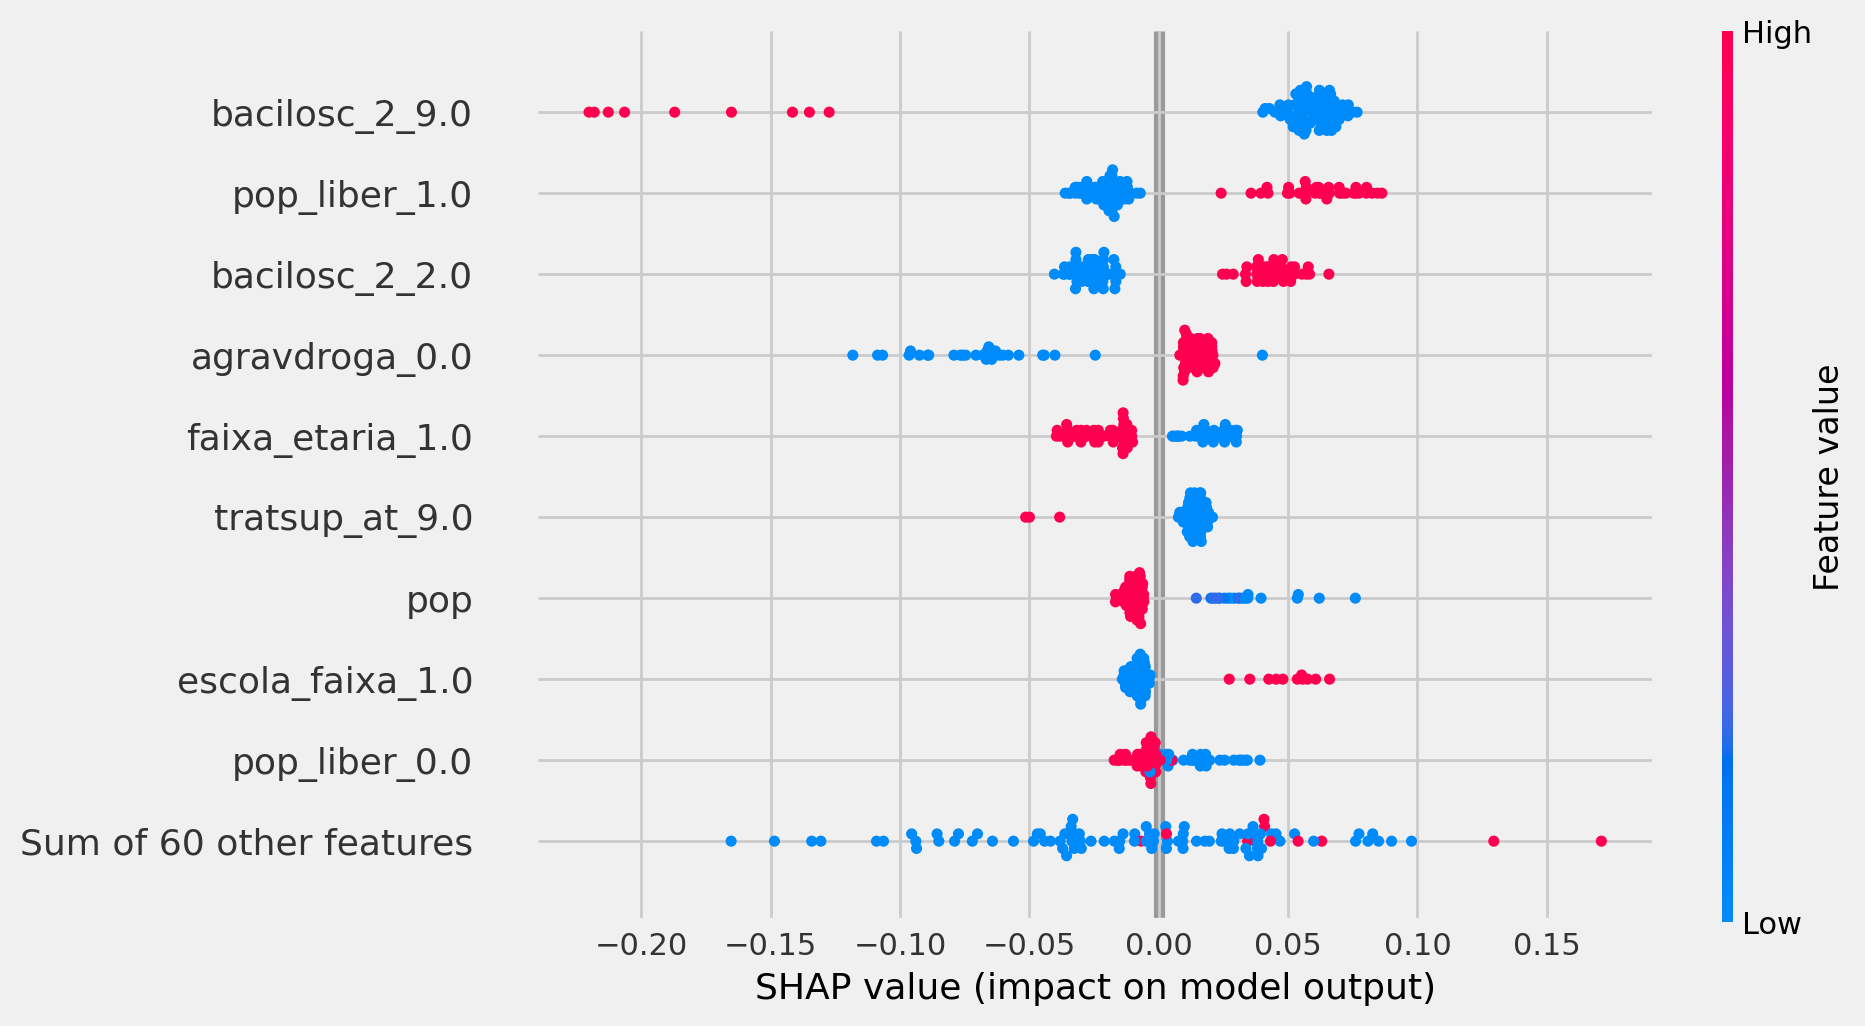

In [ ]:
import shap
import pandas as pd
import numpy as np

# =====================================================
# Seleciona um conjunto de fundo (background)
# =====================================================

background = shap.sample(X_train_tabpfn, 100, random_state=seed)

# =====================================================
# Cria o explicador SHAP
# =====================================================

explainer = shap.Explainer(
    tabpfn.predict_proba,
    background
)

# =====================================================
# Calcula os valores SHAP
# (use poucas amostras inicialmente para acelerar)
# =====================================================

X_explain = X_train_tabpfn.iloc[:100]

shap_values = explainer(X_explain)

# =====================================================
# Gráfico resumo
# =====================================================

shap.plots.beeswarm(shap_values[:, :, 1])

In [ ]:
importance = pd.DataFrame({
    "Variavel": X_explain.columns,
    "SHAP": np.abs(shap_values.values[:, :, 1]).mean(axis=0)
})

importance = (
    importance
    .sort_values("SHAP", ascending=False)
    .head(20)
)

print(importance)

            Variavel      SHAP
33    bacilosc_2_9.0  0.070626
38     pop_liber_1.0  0.035502
31    bacilosc_2_2.0  0.034356
49    agravdroga_0.0  0.032665
66  faixa_etaria_1.0  0.021176
36    tratsup_at_9.0  0.015393
0                pop  0.014848
58  escola_faixa_1.0  0.012858
37     pop_liber_0.0  0.008927
68  faixa_etaria_3.0  0.008718
34    tratsup_at_1.0  0.008334
67  faixa_etaria_2.0  0.008213
40       pop_rua_0.0  0.006738
29    cultura_es_4.0  0.006135
23    bacilosc_e_1.0  0.005950
1        cs_sexo_0.0  0.005812
2        cs_sexo_1.0  0.005019
26    cultura_es_1.0  0.004461
35    tratsup_at_2.0  0.004411
50    agravdroga_1.0  0.004351


In [ ]:
top20shap = importance.head(20)

print("\nTop 20 variáveis mais importantes:")
print(top20shap)


Top 20 variáveis mais importantes:
            Variavel      SHAP
33    bacilosc_2_9.0  0.070626
38     pop_liber_1.0  0.035502
31    bacilosc_2_2.0  0.034356
49    agravdroga_0.0  0.032665
66  faixa_etaria_1.0  0.021176
36    tratsup_at_9.0  0.015393
0                pop  0.014848
58  escola_faixa_1.0  0.012858
37     pop_liber_0.0  0.008927
68  faixa_etaria_3.0  0.008718
34    tratsup_at_1.0  0.008334
67  faixa_etaria_2.0  0.008213
40       pop_rua_0.0  0.006738
29    cultura_es_4.0  0.006135
23    bacilosc_e_1.0  0.005950
1        cs_sexo_0.0  0.005812
2        cs_sexo_1.0  0.005019
26    cultura_es_1.0  0.004461
35    tratsup_at_2.0  0.004411
50    agravdroga_1.0  0.004351


####Rodando modelo reduzido

In [ ]:
from tabpfn_client import TabPFNClassifier
from sklearn.metrics import roc_auc_score

# Seleciona as 20 variáveis mais importantes
top20_shap = importance.head(20)['Variavel'].tolist()

print("Top 20 variáveis:")
print(top20_shap)

# Conjunto de treino reduzido
X_train_top20shap = X_train_tabpfn[top20_shap]

# Novo modelo
tabpfn_top20_shap = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

# Ajuste
tabpfn_top20_shap.fit(X_train_top20shap, y_train_tabpfn)

# Probabilidades previstas no treino
y_proba_train_shap = tabpfn_top20_shap.predict_proba(X_train_top20shap)[:, 1]

Top 20 variáveis:
['bacilosc_2_9.0', 'pop_liber_1.0', 'bacilosc_2_2.0', 'agravdroga_0.0', 'faixa_etaria_1.0', 'tratsup_at_9.0', 'pop', 'escola_faixa_1.0', 'pop_liber_0.0', 'faixa_etaria_3.0', 'tratsup_at_1.0', 'faixa_etaria_2.0', 'pop_rua_0.0', 'cultura_es_4.0', 'bacilosc_e_1.0', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cultura_es_1.0', 'tratsup_at_2.0', 'agravdroga_1.0']
00:00 Fitting... \

00:04 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!


In [ ]:
from sklearn.metrics import roc_auc_score

# Assegura que X_test_novo usa as mesmas colunas que X_train_top20shap
X_test_top20shap = X_test[top20_shap]

# Probabilidades no conjunto de teste
y_pred_proba_tabpfn_novo = (
    tabpfn_top20_shap.predict_proba(X_test_top20shap)[:, 1]
)

# AUC do teste
auc_test_tabpfn_novo = roc_auc_score(
    y_test,
    y_pred_proba_tabpfn_novo
)

00:03 Predicting... Done!


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_novo = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

scores = cross_val_score(
    tabpfn_novo,
    X_train_top20shap,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())

00:03 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
00:05 Fitting... Done!
00:02 Predicting... Done!
00:03 Fitting... Done!
00:02 Predicting... Done!
00:04 Fitting... Done!
00:02 Predicting... Done!
[0.76843208 0.79277005 0.79724709 0.76155859 0.80551517]
0.7851045980353819


In [ ]:
auc_cv_novo_tabpfn = scores.mean()

In [ ]:
auc_cv_novo_tabpfn

np.float64(0.7851045980353819)

In [ ]:
# Bases com variáveis selecionadas
X_train_novo = X_train[top20_shap].copy()
X_test_novo = X_test[top20_shap].copy()

# Unificando com a variável alvo
df_train_novo = pd.concat([X_train_novo, y_train], axis=1)
df_test_novo = pd.concat([X_test_novo, y_test], axis=1)

####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn_novo.pkl"

joblib.dump(tabpfn_novo, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn_novo.pkl


In [ ]:
joblib.dump(
    {
        "model_tabpfn_novo": tabpfn_novo,
        "auc_cv_tabpfn_novo": auc_cv_novo_tabpfn,
        "auc_test_tabpfn_novo": auc_test_tabpfn_novo,
        "features": list(X_train_novo.columns)
    },
    caminho
)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn_novo.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn_novo = data["model_tabpfn_novo"]
auc_cv_tabpfn_novo = data["auc_cv_tabpfn_novo"]
auc_test_tabpfn_novo = data["auc_test_tabpfn_novo"]
features_tabpfn = data["features"]

####Salvando dataframe boruta

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_tabpfnboruta_ro_2015_2025.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_tabpfnboruta_ro_2015_2025.csv"
df_test.to_csv(path_to_save_test, index = False)

###Lendo dataframe

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_tabpfnboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_tabpfnboruta_ro_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train_novo=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test_novo=df_test.drop(columns = "cura")
y_test=df_test.cura

### Retreino do Modelo

In [ ]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token(TOKEN_tabpfn_client)
clf = TabPFNClassifier(random_state=seed)
clf.fit(X_train_novo, y_train)
predictions = clf.predict(X_test_novo)

00:03 Fitting... Done!
00:02 Predicting... Done!


In [ ]:
tabpfn_novo = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

X_train_novo_tabpfn = df_train.drop(columns="cura")
y_train_tabpfn = df_train["cura"]

tabpfn_novo.fit(
    X_train_novo_tabpfn,
    y_train_tabpfn
)

00:00 Fitting... \

00:02 Fitting... Done!


TabPFNClassifier(client_options=ClientOptions(timeout=900.0,
                                              headers={'sentry-trace': '79a0eb9924c248bfb1d515a7603bc9a9'}),
                 ignore_pretraining_limits=True, random_state=42)

In [ ]:
X_train_novo_tabpfn.shape

(1193, 20)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# ======================================
# Validação cruzada (somente treino)
# ======================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

tabpfn_cv = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

auc_scores = cross_val_score(
    tabpfn_cv,
    X_train_novo_tabpfn,
    y_train_tabpfn,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1  # recomendado para TabPFN
)

auc_cv_novo_tabpfn = auc_scores.mean()

print(f"AUC CV TabPFN: {auc_cv_novo_tabpfn:.4f}")
print(f"Desvio padrão: {auc_scores.std():.4f}")
print(f"AUC por fold: {auc_scores}")

00:03 Fitting... Done!
00:02 Predicting... Done!
00:00 Fitting... \

00:02 Fitting... Done!
00:02 Predicting... Done!
00:03 Fitting... Done!
00:02 Predicting... Done!
00:03 Fitting... Done!
00:02 Predicting... Done!
00:02 Fitting... Done!
00:02 Predicting... Done!
AUC CV TabPFN: 0.7851
Desvio padrão: 0.0171
AUC por fold: [0.76843208 0.79277005 0.79724709 0.76155859 0.80551517]


#### Metricas threshold

In [ ]:
tabpfn_novo.fit(X_train_novo_tabpfn, y_train_tabpfn)

y_prob_novo_tabpfn = tabpfn_novo.predict_proba(X_test_novo)[:, 1]
auc_test_tabpfn_novo = roc_auc_score(y_test, y_prob_novo_tabpfn)

print(f"AUC CV (treino): {auc_cv_novo_tabpfn:.4f}")
print(f"AUC Teste      : {auc_test_tabpfn_novo:.4f}")

00:00 Fitting... \

00:02 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
AUC CV (treino): 0.7851
AUC Teste      : 0.8128


####Salvando modelo boruta

In [ ]:
import joblib

caminho = "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn_novo.pkl"

joblib.dump(tabpfn_novo, caminho)

print(f"✅ Modelo salvo em: {caminho}")

✅ Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn_novo.pkl


In [ ]:
joblib.dump(
    {
        "model_tabpfn_novo": tabpfn_novo,
        "auc_cv_tabpfn_novo": auc_cv_novo_tabpfn,
        "auc_test_tabpfn_novo": auc_test_tabpfn_novo,
        "features": list(X_train_novo.columns)
    },
    caminho
)

['/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn_novo.pkl']

In [ ]:
data = joblib.load(caminho)

tabpfn_novo = data["model_tabpfn_novo"]
auc_cv_tabpfn_novo = data["auc_cv_tabpfn_novo"]
features_tabpfn = data["features"]

####Comparacao modelo completo e boruta - tabela

In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_processados2_ro_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_teste_processados2_ro_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
# Separação das bases entre X_train, X_test, y_train, y_test

X_train = df_train.drop(columns=["cura"])
y_train = df_train["cura"]

X_test = df_test.drop(columns=["cura"])
y_test = df_test["cura"]

In [ ]:
import joblib
import pandas as pd

# Modelo completo
data_full = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn.pkl"
)

# Modelo Boruta/Top Features
data_novo = joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn_novo.pkl"
)

auc_cv_tabpfn = data_full["auc_cv_tabpfn"]
auc_cv_tabpfn_novo = data_novo["auc_cv_tabpfn_novo"]

comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Boruta"],
    "AUC-CV": [auc_cv_tabpfn, auc_cv_tabpfn_novo]
})

print(comparacao)

if auc_cv_tabpfn > auc_cv_tabpfn_novo:
    print(f"\n🏆 Melhor modelo: Base Completa (AUC-CV = {auc_cv_tabpfn:.4f})")
elif auc_cv_tabpfn_novo > auc_cv_tabpfn:
    print(f"\n🏆 Melhor modelo: Boruta (AUC-CV = {auc_cv_tabpfn_novo:.4f})")
else:
    print("\n🤝 Os dois modelos possuem o mesmo AUC-CV.")

          Modelo    AUC-CV
0  Base Completa  0.776213
1         Boruta  0.785105

🏆 Melhor modelo: Boruta (AUC-CV = 0.7851)


# Comparando todos os modelos

In [ ]:
!pip install tabpfn-client
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score
from tabpfn_client import TabPFNClassifier # Added import for TabPFNClassifier

rf = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf.pkl")
xgb = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb.pkl")
lgb = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb.pkl")
cat = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat.pkl")
tabpfn = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn.pkl")
rf_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_rf_novo.pkl")
lgb_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_lgb_novo.pkl")
xgb_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_xgb_novo.pkl")
cat_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_cat_novo.pkl")
tabpfn_novo = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/RO/best_model_tabpfn_novo.pkl")

In [ ]:
# ===============================
# SEEDS DOS MODELOS
# ===============================

modelos = {
    "RandomForest": rf['model_rf'],
    "LGBM": lgb['model_lgb'],
    "XGBoost": xgb['model_xgb'],
    "CatBoost": cat['model_cat'],
    "TabPFN": tabpfn['model_tabpfn'],
    "RandomForest_novo": rf_novo['model_rf_novo'],
    "LGBM_novo": lgb_novo['model_lgb_novo'],
    "XGBoost_novo": xgb_novo['model_xgb_novo'],
    "CatBoost_novo": cat_novo['model_cat_novo'],
    "TabPFN_novo": tabpfn_novo['model_tabpfn_novo'],
}

for nome, modelo in modelos.items():
    try:
        params = modelo.get_params()

        seed = (
            params.get('random_state')
            or params.get('seed')
            or params.get('random_seed')
        )

        print(f"{nome}: {seed}")

    except Exception as e:
        print(f"{nome}: não foi possível obter a seed ({e})")

RandomForest: 42
LGBM: 42
XGBoost: 42
CatBoost: 42
TabPFN: 42
RandomForest_novo: 42
LGBM_novo: 42
XGBoost_novo: 42
CatBoost_novo: 42
TabPFN_novo: 42


In [ ]:
# ============================================================
# CONTAGEM REAL DE VARIÁVEIS BORUTA E AUDITORIA DOS MODELOS
# ============================================================

import pandas as pd

TARGET = "cura"

# ------------------------
# Bases pós-Boruta
# ------------------------

paths_boruta = {
    "RandomForest_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_rfboruta_ro_2015_2025.csv",

    "LGBM_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_lgbboruta_ro_2015_2025.csv",

    "XGBoost_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_xgbboruta_ro_2015_2025.csv",

    "CatBoost_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_catboruta_ro_2015_2025.csv",

    "TabPFN_novo":
    "/content/drive/MyDrive/Colab Notebooks/Artigo2_TL/dados_treino_tabpfnboruta_ro_2015_2025.csv"
}

# ------------------------
# Modelos novos
# ------------------------

modelos_novos = {
    "RandomForest_novo": rf_novo['model_rf_novo'],
    "LGBM_novo": lgb_novo['model_lgb_novo'],
    "XGBoost_novo": xgb_novo['model_xgb_novo'],
    "CatBoost_novo": cat_novo['model_cat_novo'],
    "TabPFN_novo": tabpfn_novo['model_tabpfn_novo']
}

audit_boruta = {}

for nome, caminho in paths_boruta.items():

    df_boruta = pd.read_csv(caminho)

    # Remove desfecho
    features_boruta = [c for c in df_boruta.columns if c != TARGET]

    n_features_boruta = len(features_boruta)

    modelo = modelos_novos[nome]

    # Recupera features efetivamente usadas pelo modelo
    try:

        if hasattr(modelo, "feature_names_in_"):
            features_modelo = list(modelo.feature_names_in_)

        elif hasattr(modelo, "feature_names_"):
            features_modelo = list(modelo.feature_names_)

        else:
            features_modelo = []

        n_features_modelo = len(features_modelo)

        faltantes = sorted(
            list(set(features_boruta) - set(features_modelo))
        )

        extras = sorted(
            list(set(features_modelo) - set(features_boruta))
        )

        status = (
            "OK"
            if len(faltantes) == 0 and len(extras) == 0
            else "DIVERGENTE"
        )

    except Exception as e:

        n_features_modelo = None
        faltantes = []
        extras = []
        status = f"Erro: {e}"

    audit_boruta[nome] = {
        "N_Boruta": n_features_boruta,
        "N_Modelo": n_features_modelo,
        "Status": status,
        "Faltantes": faltantes,
        "Extras": extras
    }

# ------------------------
# Mostrar auditoria
# ------------------------

print("\n" + "="*60)
print("AUDITORIA BORUTA × MODELO")
print("="*60)

for nome, info in audit_boruta.items():

    print(f"\n{nome}")
    print(f"Variáveis Boruta : {info['N_Boruta']}")
    print(f"Variáveis Modelo : {info['N_Modelo']}")
    print(f"Status           : {info['Status']}")

    if len(info['Faltantes']) > 0:
        print(f"\nFaltantes ({len(info['Faltantes'])}):")
        print(info['Faltantes'])

    if len(info['Extras']) > 0:
        print(f"\nExtras ({len(info['Extras'])}):")
        print(info['Extras'])


AUDITORIA BORUTA × MODELO

RandomForest_novo
Variáveis Boruta : 20
Variáveis Modelo : 20
Status           : OK

LGBM_novo
Variáveis Boruta : 20
Variáveis Modelo : 20
Status           : OK

XGBoost_novo
Variáveis Boruta : 20
Variáveis Modelo : 20
Status           : OK

CatBoost_novo
Variáveis Boruta : 20
Variáveis Modelo : 20
Status           : OK

TabPFN_novo
Variáveis Boruta : 20
Variáveis Modelo : 0
Status           : DIVERGENTE

Faltantes (20):
['agravdroga_0.0', 'agravdroga_1.0', 'bacilosc_2_2.0', 'bacilosc_2_9.0', 'bacilosc_e_1.0', 'cs_sexo_0.0', 'cs_sexo_1.0', 'cultura_es_1.0', 'cultura_es_4.0', 'escola_faixa_1.0', 'faixa_etaria_1.0', 'faixa_etaria_2.0', 'faixa_etaria_3.0', 'pop', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_rua_0.0', 'tratsup_at_1.0', 'tratsup_at_2.0', 'tratsup_at_9.0']


In [ ]:
resultados_cv = [

    {
        "Modelo": "RandomForest",
        "AUC_CV": rf["auc_cv_rf"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "LGBM",
        "AUC_CV": lgb["auc_cv_lgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "XGBoost",
        "AUC_CV": xgb["auc_cv_xgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "CatBoost",
        "AUC_CV": cat["auc_cv_cat"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "TabPFN",
        "AUC_CV": tabpfn["auc_cv_tabpfn"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "RandomForest_novo",
        "AUC_CV": rf_novo["auc_cv_rf_novo"],
        "N_Features": audit_boruta["RandomForest_novo"]["N_Boruta"]
    },

    {
        "Modelo": "LGBM_novo",
        "AUC_CV": lgb_novo["auc_cv_lgb_novo"],
        "N_Features": audit_boruta["LGBM_novo"]["N_Boruta"]
    },

    {
        "Modelo": "XGBoost_novo",
        "AUC_CV": xgb_novo["auc_xgb_novo"],
        "N_Features": audit_boruta["XGBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "CatBoost_novo",
        "AUC_CV": cat_novo["auc_cv_cat_novo"],
        "N_Features": audit_boruta["CatBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "TabPFN_novo",
        "AUC_CV": tabpfn_novo["auc_cv_tabpfn_novo"],
        "N_Features": audit_boruta["TabPFN_novo"]["N_Boruta"]
    }
]

df_cv = (
    pd.DataFrame(resultados_cv)
      .sort_values("AUC_CV", ascending=False)
      .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("RANKING FINAL DOS MODELOS - AUC DA VALIDAÇÃO CRUZADA")
print("=" * 60)
print(df_cv)




RANKING FINAL DOS MODELOS - AUC DA VALIDAÇÃO CRUZADA
              Modelo    AUC_CV  N_Features
0       RandomForest  0.785576          69
1        TabPFN_novo  0.785105          20
2          LGBM_novo  0.784604          20
3  RandomForest_novo  0.783529          20
4           CatBoost  0.781805          69
5      CatBoost_novo  0.781639          20
6            XGBoost  0.780761          69
7       XGBoost_novo  0.778401          20
8               LGBM  0.776485          69
9             TabPFN  0.776213          69


In [ ]:
resultados_test = [

    {
        "Modelo": "RandomForest",
        "AUC_Test": rf["auc_test_rf"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "LGBM",
        "AUC_Test": lgb["auc_test_lgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "XGBoost",
        "AUC_Test": xgb["auc_test_xgb"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "CatBoost",
        "AUC_Test": cat["auc_test_cat"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "TabPFN",
        "AUC_Test": tabpfn["auc_test_tabpfn"],
        "N_Features": X_train.shape[1]
    },

    {
        "Modelo": "RandomForest_novo",
        "AUC_Test": rf_novo["auc_test_rf_novo"],
        "N_Features": audit_boruta["RandomForest_novo"]["N_Boruta"]
    },

    {
        "Modelo": "LGBM_novo",
        "AUC_Test": lgb_novo["auc_test_lgb_novo"],
        "N_Features": audit_boruta["LGBM_novo"]["N_Boruta"]
    },

    {
        "Modelo": "XGBoost_novo",
        "AUC_Test": xgb_novo["auc_test_xgb_novo"],
        "N_Features": audit_boruta["XGBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "CatBoost_novo",
        "AUC_Test": cat_novo["auc_test_cat_novo"],
        "N_Features": audit_boruta["CatBoost_novo"]["N_Boruta"]
    },

    {
        "Modelo": "TabPFN_novo",
        "AUC_Test": tabpfn_novo["auc_test_tabpfn_novo"],
        "N_Features": len(tabpfn_novo["features"])
    }
]

df_test = (
    pd.DataFrame(resultados_test)
      .sort_values("AUC_Test", ascending=False)
      .reset_index(drop=True)
)

print("\n")
print("=" * 60)
print("RANKING FINAL DOS MODELOS - AUC-ROC DO TESTE")
print("=" * 60)
print(df_test)



RANKING FINAL DOS MODELOS - AUC-ROC DO TESTE
              Modelo  AUC_Test  N_Features
0           CatBoost  0.961341          69
1            XGBoost  0.885271          69
2               LGBM  0.879857          69
3       RandomForest  0.874187          69
4      CatBoost_novo  0.874052          20
5          LGBM_novo  0.872963          20
6             TabPFN  0.867277          69
7  RandomForest_novo  0.829299          20
8       XGBoost_novo  0.824741          20
9        TabPFN_novo  0.812778          20


In [ ]:
# ============================================================
# ANÁLISE ADICIONAL:
# ΔAUC + IC95% DA AUC DO TESTE POR BOOTSTRAP
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from tabpfn_client import TabPFNClassifier, set_access_token
#site: https://ux.priorlabs.ai/home
set_access_token(TOKEN_tabpfn_client)


# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------

N_BOOTSTRAP = 2000
RANDOM_STATE = seed

rng = np.random.RandomState(RANDOM_STATE)


# ============================================================
# FUNÇÃO PARA OBTER AS FEATURES UTILIZADAS PELO MODELO
# ============================================================

def obter_features_modelo(nome, modelo):

    # TabPFN_novo
    if nome == "TabPFN_novo":
        return list(tabpfn_novo["features"])

    # Modelos que possuem feature_names_in_
    if hasattr(modelo, "feature_names_in_"):
        return list(modelo.feature_names_in_)

    # Modelos que possuem feature_names_
    if hasattr(modelo, "feature_names_"):
        return list(modelo.feature_names_)

    # Caso não seja possível recuperar
    return list(X_test.columns)


# ============================================================
# FUNÇÃO DE BOOTSTRAP PARA AUC
# ============================================================

def bootstrap_auc(y_true, y_pred_proba,
                  n_bootstrap=2000,
                  random_state=42):

    rng = np.random.RandomState(random_state)

    y_true = np.asarray(y_true)
    y_pred_proba = np.asarray(y_pred_proba)

    auc_original = roc_auc_score(y_true, y_pred_proba)

    auc_bootstrap = []

    n = len(y_true)

    for i in range(n_bootstrap):

        # Amostragem com reposição
        indices = rng.randint(0, n, size=n)

        y_boot = y_true[indices]
        pred_boot = y_pred_proba[indices]

        # É necessário haver as duas classes
        if len(np.unique(y_boot)) < 2:
            continue

        auc_boot = roc_auc_score(y_boot, pred_boot)

        auc_bootstrap.append(auc_boot)

    auc_bootstrap = np.array(auc_bootstrap)

    # Média bootstrap
    auc_media_bootstrap = np.mean(auc_bootstrap)

    # Viés bootstrap
    # média bootstrap - AUC original
    vies_bootstrap = auc_media_bootstrap - auc_original

    # IC95% percentil
    ic_inf = np.percentile(auc_bootstrap, 2.5)
    ic_sup = np.percentile(auc_bootstrap, 97.5)

    return {
        "AUC_original": auc_original,
        "AUC_bootstrap_media": auc_media_bootstrap,
        "Vies_bootstrap": vies_bootstrap,
        "IC95_inf": ic_inf,
        "IC95_sup": ic_sup,
        "N_bootstrap": len(auc_bootstrap)
    }


# ============================================================
# DICIONÁRIO DOS MODELOS
# ============================================================

modelos_completos = {

    "RandomForest": rf["model_rf"],

    "LGBM": lgb["model_lgb"],

    "XGBoost": xgb["model_xgb"],

    "CatBoost": cat["model_cat"],

    "TabPFN": tabpfn["model_tabpfn"],

    "RandomForest_novo": rf_novo["model_rf_novo"],

    "LGBM_novo": lgb_novo["model_lgb_novo"],

    "XGBoost_novo": xgb_novo["model_xgb_novo"],

    "CatBoost_novo": cat_novo["model_cat_novo"],

    "TabPFN_novo": tabpfn_novo["model_tabpfn_novo"]
}


# ============================================================
# CALCULAR AUC DO TESTE + BOOTSTRAP
# ============================================================

resultados_bootstrap = []


for nome, modelo in modelos_completos.items():

    print(f"\nProcessando: {nome}")

    # --------------------------------------------------------
    # Features utilizadas pelo modelo
    # --------------------------------------------------------

    features_modelo = obter_features_modelo(nome, modelo)

    # Verificação
    faltantes = [
        f for f in features_modelo
        if f not in X_test.columns
    ]

    if len(faltantes) > 0:

        print("ERRO: variáveis ausentes no X_test:")
        print(faltantes)

        continue

    # --------------------------------------------------------
    # Seleciona exatamente as variáveis utilizadas pelo modelo
    # --------------------------------------------------------

    X_test_modelo = X_test[features_modelo].copy()

    # --------------------------------------------------------
    # Probabilidade da classe positiva
    # --------------------------------------------------------

    y_pred_proba = modelo.predict_proba(X_test_modelo)[:, 1]

    # --------------------------------------------------------
    # AUC do teste
    # --------------------------------------------------------

    auc_test = roc_auc_score(
        y_test,
        y_pred_proba
    )

    # --------------------------------------------------------
    # AUC-CV
    # --------------------------------------------------------

    linha_cv = df_cv[
        df_cv["Modelo"] == nome
    ]

    if len(linha_cv) == 0:

        print(f"AUC-CV não encontrada para {nome}")

        continue

    auc_cv = linha_cv["AUC_CV"].iloc[0]

    # --------------------------------------------------------
    # ΔAUC
    #
    # Teste - CV
    # --------------------------------------------------------

    delta_auc = auc_test - auc_cv

    # --------------------------------------------------------
    # Bootstrap
    # --------------------------------------------------------

    boot = bootstrap_auc(
        y_true=y_test,
        y_pred_proba=y_pred_proba,
        n_bootstrap=N_BOOTSTRAP,
        random_state=RANDOM_STATE
    )

    # --------------------------------------------------------
    # Resultado
    # --------------------------------------------------------

    resultados_bootstrap.append({

        "Modelo": nome,

        "AUC_CV": auc_cv,

        "AUC_Test": auc_test,

        "Delta_AUC": delta_auc,

        "AUC_Bootstrap_Media":
            boot["AUC_bootstrap_media"],

        "Vies_Bootstrap":
            boot["Vies_bootstrap"],

        "IC95_inf":
            boot["IC95_inf"],

        "IC95_sup":
            boot["IC95_sup"],

        "N_Bootstrap":
            boot["N_bootstrap"],

        "N_Features":
            len(features_modelo)
    })


# ============================================================
# TABELA FINAL
# ============================================================

df_bootstrap = pd.DataFrame(
    resultados_bootstrap
)


# Ordenar pelo AUC do teste
df_bootstrap = (
    df_bootstrap
    .sort_values(
        "AUC_Test",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# FORMATAÇÃO
# ============================================================

df_bootstrap_formatado = df_bootstrap.copy()

colunas_auc = [
    "AUC_CV",
    "AUC_Test",
    "Delta_AUC",
    "AUC_Bootstrap_Media",
    "Vies_Bootstrap",
    "IC95_inf",
    "IC95_sup"
]

for coluna in colunas_auc:

    df_bootstrap_formatado[coluna] = (
        df_bootstrap_formatado[coluna]
        .round(4)
    )


# ============================================================
# EXIBIR RESULTADO
# ============================================================

print("\n")
print("=" * 100)
print("ANÁLISE ADICIONAL: ΔAUC + BOOTSTRAP DA AUC DO TESTE")
print("=" * 100)

print(
    df_bootstrap_formatado[
        [
            "Modelo",
            "AUC_CV",
            "AUC_Test",
            "Delta_AUC",
            "AUC_Bootstrap_Media",
            "Vies_Bootstrap",
            "IC95_inf",
            "IC95_sup",
            "N_Features"
        ]
    ]
)


Processando: RandomForest

Processando: LGBM
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10

Processando: XGBoost

Processando: CatBoost

Processando: TabPFN
00:03 Predicting... Done!

Processando: RandomForest_novo

Processando: LGBM_novo
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5

Processando: XGBoost_novo

Processando: CatBoost_novo

Processando: TabPFN_novo
00:02 Predicting... Done!


ANÁLISE ADICIONAL: ΔAUC + BOOTSTRAP DA AUC DO TESTE
              Modelo  AUC_CV  AUC_Test  Delta_AUC  AUC_Bootstrap_Media  \
0           CatBoost  0.7818    0.9613     0.1795               0.9613   
1            XGBoost  0.7808    0.8853     0.1045               0.8852   
2               LGBM  0.7765    0.8799     0.1034               0.8797   
3       RandomForest  0.7856    0.8742     0.0886               0.8740   
4      CatBoost_novo  0.7816    0